In [43]:
%matplotlib inline
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import distance
from scipy import stats
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [44]:
"""
You can start the code from here
"""
#Import the actual data
df_biofilm_filtered = pd.read_csv('Figurewise raw data/Biofilm_filtered.csv', index_col = 0)
df_biofilm_filtered.head()

,3,8,28,32,42,64,70,78,100,108,...,t_27_enrichment,t_39_enrichment,t_45_enrichment,t_63_enrichment,t_73_enrichment,t_81_enrichment,t_99_enrichment,t_107_enrichment,t_115_enrichment,t_137_enrichment
barcode,,,,,,,,,,,,,,,,,,,,,
GCGTATCGGAACTAGAAGGG,0,1,7,3,1,0,3,1,3,3,...,0.301030,0.602060,0.301030,0.602060,1.255273,1.146128,0.903090,0.000000,0.000000,0.000000
ACTGGAGAGACGCTCCAAGT,0,5,1,0,2,0,1,2,0,0,...,0.301030,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.301030,0.000000
GTTTTTAAATGTGTGCCCGG,1,4,1,3,9,0,4,0,0,0,...,-0.301030,-0.301030,0.397940,0.301030,-0.301030,-0.301030,-0.301030,-0.301030,-0.301030,-0.301030
GTACTAAATTGATGCCCATT,10,0,0,0,0,0,0,2,3,0,...,-0.740363,-1.041393,-1.041393,-0.740363,-1.041393,-1.041393,-1.041393,-1.041393,-1.041393,-1.041393
GGCCAAAGTACCTGTTAAAT,7,4,4,4,6,10,5,9,3,4,...,-0.903090,-0.425969,0.096910,-0.903090,-0.903090,-0.425969,-0.903090,-0.903090,-0.425969,-0.903090


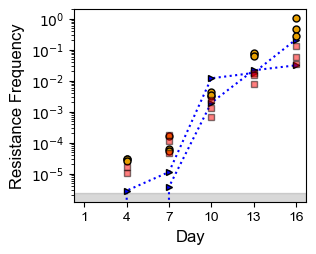

In [45]:
df_CFU_dynamics = pd.read_excel('Figurewise raw data/6B. Amikacin CFU Dynamics.xlsx')
df_CFU_dynamics = df_CFU_dynamics.loc[[1,4,7,10,13,16]]

plt.figure(figsize= [3,2.5])

plt.plot(df_CFU_dynamics.Time, df_CFU_dynamics.Plank_WellA_res/df_CFU_dynamics.Plank_WellA, ':>', color = 'blue',  markersize = 5,\
         markeredgecolor = 'black', label = 'LB')
plt.plot(df_CFU_dynamics.Time, df_CFU_dynamics.Plank_WellB_res/df_CFU_dynamics.Plank_WellB, ':>', color = 'blue',  markersize = 5,\
         markeredgecolor = 'black', label = 'LB')

plt.plot(df_CFU_dynamics.Time, df_CFU_dynamics.DiscA1_res/df_CFU_dynamics.DiscA1, 'o', color = '#E69F00',  markersize = 5,\
         markeredgecolor = 'black', label = 'LB')
plt.plot(df_CFU_dynamics.Time, df_CFU_dynamics.DiscA2_res/df_CFU_dynamics.DiscA2, 'o', color = '#E69F00',  markersize = 5,\
         markeredgecolor = 'black', label = 'LB')
plt.plot(df_CFU_dynamics.Time, df_CFU_dynamics.DiscA3_res/df_CFU_dynamics.DiscA3, 'o', color = '#E69F00',  markersize = 5,\
         markeredgecolor = 'black', label = 'LB')

plt.plot(df_CFU_dynamics.Time, df_CFU_dynamics.DiscB1_res/df_CFU_dynamics.DiscB1, 's', color = 'red', alpha = 0.5, markersize = 5,\
         markeredgecolor = 'black', label = '')
plt.plot(df_CFU_dynamics.Time, df_CFU_dynamics.DiscB2_res/df_CFU_dynamics.DiscB2, 's', color = 'red', alpha = 0.5, markersize = 5,\
         markeredgecolor = 'black', label = '')
plt.plot(df_CFU_dynamics.Time, df_CFU_dynamics.DiscB3_res/df_CFU_dynamics.DiscB3, 's', color = 'red', alpha = 0.5, markersize = 5,\
         markeredgecolor = 'black', label = '')

mean_resistance = (df_CFU_dynamics.FlaskA_res/df_CFU_dynamics.FlaskA).dropna().mean()
std_resistance = (df_CFU_dynamics.FlaskA_res/df_CFU_dynamics.FlaskA).dropna().std()

plt.axhspan(mean_resistance + 1.96*std_resistance, mean_resistance - 1.96*std_resistance, color = 'gray', alpha = 0.3)

plt.yscale('log')
#plt.ylim([10**0, 10**8])

plt.xlabel('Day', fontname = 'Arial', fontsize = 12)
plt.ylabel('Resistance Frequency', fontname = 'Arial', fontsize = 12)

plt.xticks([1,4,7,10,13,16],[1,4,7,10,13,16], fontname = 'Arial', fontsize = 10);

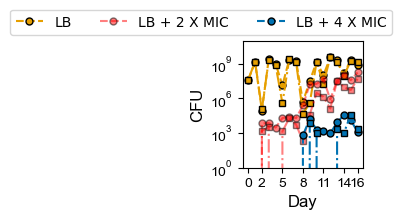

In [46]:
df_CFU_dynamics = pd.read_excel('Figurewise raw data/6B. Amikacin CFU Dynamics.xlsx')
df_CFU_dynamics

plt.figure(figsize= [3,2.5])

plt.plot(df_CFU_dynamics.Time, df_CFU_dynamics.Plank_WellA, '--o', color = '#E69F00',  markersize = 5,\
         markeredgecolor = 'black', label = 'LB')

plt.plot(df_CFU_dynamics.Time, df_CFU_dynamics.Plank_WellB, '-.s', color = '#E69F00',  markersize = 5,\
         markeredgecolor = 'black', label = '')

plt.plot(df_CFU_dynamics.Time, df_CFU_dynamics.Plank_WellA_res, '--o', color = 'red', alpha = 0.5, markersize = 5,\
         markeredgecolor = 'black', label = 'LB + 2 X MIC')

plt.plot(df_CFU_dynamics.Time, df_CFU_dynamics.Plank_WellB_res, '-.s', color = 'red', alpha = 0.5, markersize = 5,\
         markeredgecolor = 'black', label = '')

plt.plot(df_CFU_dynamics.Time, df_CFU_dynamics.Plank_WellA_res4, '--o', color = '#0072B2', markersize = 5,\
         markeredgecolor = 'black', label = 'LB + 4 X MIC')

plt.plot(df_CFU_dynamics.Time, df_CFU_dynamics.Plank_WellB_res4, '-.s', color = '#0072B2', markersize = 5,\
         markeredgecolor = 'black', label = '')

plt.yscale('log')
plt.ylim([10**0, 10**11])

plt.xlabel('Day', fontname = 'Arial', fontsize = 12)
plt.ylabel('CFU', fontname = 'Arial', fontsize = 12)

plt.xticks([0,2,5,8,11,14,16], fontname = 'Arial', fontsize = 10);
plt.yticks(fontname = 'Arial', fontsize = 10);

plt.legend(ncol = 3, fontsize = 10, bbox_to_anchor = [1.3,1.3])
plt.tight_layout()
plt.savefig('Figures paper/Amk_CFUdynamics_w_legend.svg', format = 'svg', dpi = 300)

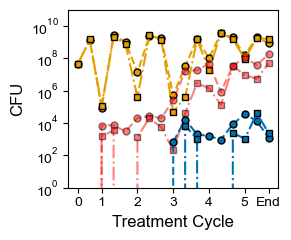

In [47]:
df_CFU_dynamics = pd.read_excel('Figurewise raw data/6B. Amikacin CFU Dynamics.xlsx')
df_CFU_dynamics

plt.figure(figsize= [3,2.5])

plt.plot(df_CFU_dynamics.Time, df_CFU_dynamics.Plank_WellA, '--o', color = '#E69F00',  markersize = 5,\
         markeredgecolor = 'black', label = 'LB')

plt.plot(df_CFU_dynamics.Time, df_CFU_dynamics.Plank_WellB, '-.s', color = '#E69F00',  markersize = 5,\
         markeredgecolor = 'black', label = '')

plt.plot(df_CFU_dynamics.Time, df_CFU_dynamics.Plank_WellA_res, '--o', color = 'red', alpha = 0.5, markersize = 5,\
         markeredgecolor = 'black', label = 'LB + 2 X MIC')

plt.plot(df_CFU_dynamics.Time, df_CFU_dynamics.Plank_WellB_res, '-.s', color = 'red', alpha = 0.5, markersize = 5,\
         markeredgecolor = 'black', label = '')

plt.plot(df_CFU_dynamics.Time, df_CFU_dynamics.Plank_WellA_res4, '--o', color = '#0072B2', markersize = 5,\
         markeredgecolor = 'black', label = 'LB + 4 X MIC')

plt.plot(df_CFU_dynamics.Time, df_CFU_dynamics.Plank_WellB_res4, '-.s', color = '#0072B2', markersize = 5,\
         markeredgecolor = 'black', label = '')

plt.yscale('log')
plt.ylim([10**0, 10**11])

plt.xlabel('Treatment Cycle', fontname = 'Arial', fontsize = 12)
plt.ylabel('CFU', fontname = 'Arial', fontsize = 12)

plt.xticks([0,2,5,8,11,14,16],[0,1,2,3,4,5,'End'], fontname = 'Arial', fontsize = 10);
plt.yticks(fontname = 'Arial', fontsize = 10);

#plt.legend(ncol = 3, fontsize = 10, bbox_to_anchor = [1.3,1.3])
plt.tight_layout()
plt.savefig('Figures paper/Amk_CFUdynamics_w0_legend.svg', format = 'svg', dpi = 300)

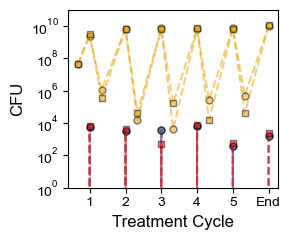

In [48]:
df_CFU_dynamics = pd.read_excel('Figurewise raw data/6B. Amikacin CFU Dynamics.xlsx')
df_CFU_dynamics

plt.figure(figsize= [3,2.5])

df_plot = df_CFU_dynamics[['Time', 'FlaskA' , 'FlaskA_res', 'FlaskA_res4']].dropna()

plt.plot(df_plot.Time, df_plot.FlaskA, '--o', color = '#E69F00', alpha = 0.5, markersize = 5,\
         markeredgecolor = 'black')

plt.plot(df_plot.Time, df_plot.FlaskA_res, '--o', color = 'red', alpha = 0.5, markersize = 5,\
         markeredgecolor = 'black')

plt.plot(df_plot.Time, df_plot.FlaskA_res, '--o', color = '#0072B2', alpha = 0.5, markersize = 5,\
         markeredgecolor = 'black')

df_plot = df_CFU_dynamics[['Time', 'FlaskB' , 'FlaskB_res', 'FlaskB_res4']].dropna()

plt.plot(df_plot.Time, df_plot.FlaskB, '--s', color = '#E69F00', alpha = 0.5, markersize = 5,\
         markeredgecolor = 'black')

plt.plot(df_plot.Time, df_plot.FlaskB_res, '--s', color = 'red', alpha = 0.5, markersize = 5,\
         markeredgecolor = 'black')

plt.plot(df_plot.Time, df_plot.FlaskB_res4, '--s', color = '#0072B2', alpha = 0.5, markersize = 5,\
         markeredgecolor = 'black')

plt.yscale('log')

plt.yscale('log')
plt.ylim([10**0, 10**11])

plt.xlabel('Treatment Cycle', fontname = 'Arial', fontsize = 12)
plt.ylabel('CFU', fontname = 'Arial', fontsize = 12)

plt.xticks([1,4,7,10,13,16], [1,2,3,4,5,'End'], fontname = 'Arial', fontsize = 10);
plt.yticks(fontname = 'Arial', fontsize = 10);
plt.tight_layout()
plt.savefig('Figures paper/Amk_CFUdynamicsflask_wo_legend.svg', format = 'svg', dpi = 300)

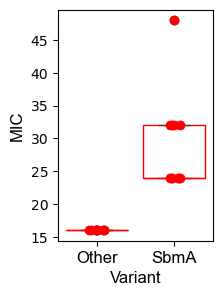

In [79]:
df_MIC = pd.read_excel('Figurewise raw data/6C. MIC_Clones.xlsx')
df_MIC.to_excel('Figurewise raw data/Supplementary Figure 16 MIC Clones.xlsx')
fig,ax = plt.subplots(figsize = [2,3])

sns.stripplot(x='Experiment', y='MIC', data=df_MIC, color='red', s=7, marker = 'o')

sns.boxplot(x='Experiment', y='MIC', data=df_MIC,boxprops=dict(facecolor='white', edgecolor='red'),
    medianprops=dict(color='red'))

plt.xlabel('Variant', fontname = 'Arial', fontsize = 12)
plt.ylabel('MIC', fontname = 'Arial', fontsize = 12)

plt.xticks([0,1],['Other','SbmA'], fontname = 'Arial', fontsize = 12)

plt.savefig('Figures paper/MIC by loc amk.svg', format = 'svg', dpi = 300)


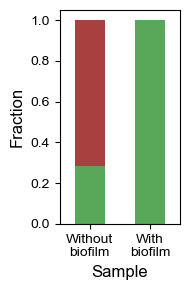

In [64]:
df_mutbysample = pd.read_excel('Figurewise raw data/6D. Mut_bylocAMK.xlsx', index_col = 0)
df_mutbysample['Without_p'] = df_mutbysample.Without/df_mutbysample.Without.sum()
df_mutbysample['With_p'] = df_mutbysample['With']/df_mutbysample['With'].sum()
df_mutbysample

fig,ax = plt.subplots(figsize = [2,3])
df_mutbysample[['Without_p','With_p']].transpose().plot.bar(ax = ax, stacked = True, color = ['forestgreen','darkred'], alpha = 0.75, legend = False)
#plt.legend(ncol = 2, bbox_to_anchor = [1.1,1.15], fontsize = 10)
plt.xticks(np.arange(2),['Without\nbiofilm','With\nbiofilm'], rotation = 0, fontname = 'Arial', fontsize = 10)
plt.yticks(fontname = 'Arial', fontsize = 10)
plt.ylabel('Fraction',fontname = 'Arial', fontsize = 12)
plt.xlabel('Sample',fontname = 'Arial', fontsize = 12)
plt.tight_layout()
plt.savefig('Figures paper/Mutated by loc amk.svg', format = 'svg', dpi = 300)

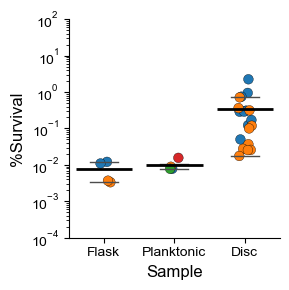

In [65]:
df_Bottleneck = pd.read_excel('Antibiotic_bottleneck.xlsx')
df_Bottleneck.to_excel('Figurewise raw data/Supplementary figure 14C Antibiotic killing.xlsx')
df_Bottleneck['Killing'] = (df_Bottleneck.W_treatment/df_Bottleneck.WO_treatment)*100
df_Bottleneck

"""
Following plot is to compare number of unique barcodes detected in the initial time points
"""
plt.figure(figsize = [3,3])

#Construcy a strip plot to show each time point individually
sns.stripplot(data=df_Bottleneck, x="Sample", y="Killing",  hue = 'Replicate', s=7, edgecolor='black', linewidth=0.25, legend = False)

#Construct a box plot to show median and variance in the population
sns.boxplot(data=df_Bottleneck, x="Sample", y="Killing", showmeans = True, meanline = True,\
            medianprops = {'visible':False}, whiskerprops={'visible':False},zorder = 10, showfliers = False, showbox = False,\
           showcaps = True, meanprops = {'color': 'k', 'ls':'-','lw':2})
plt.yscale('log')

plt.ylabel('%Survival', fontname = 'arial', fontsize = 12)
plt.xlabel('Sample', fontname = 'arial', fontsize = 12)
plt.xticks(fontname = 'arial', fontsize = 10)
plt.yticks(fontname = 'arial', fontsize = 10)

# Remove top and right spines
sns.despine(top=True, right=True)
plt.ylim(0.0001,100)
plt.tight_layout()

plt.tight_layout()
plt.savefig('Figures paper/Amk_Survival_Frequency.svg', format = 'svg', dpi = 300)

In [66]:
#Compare the planktonic and the Disc samples
print(stats.ks_2samp(df_Bottleneck.loc[df_Bottleneck.Sample == 'Planktonic'].Killing, \
                      df_Bottleneck.loc[df_Bottleneck.Sample == 'Disc'].Killing))

print(stats.ks_2samp(df_Bottleneck.loc[df_Bottleneck.Sample == 'Flask'].Killing, \
                      df_Bottleneck.loc[df_Bottleneck.Sample == 'Disc'].Killing))

KstestResult(statistic=np.float64(1.0), pvalue=np.float64(0.0001882175795219274), statistic_location=np.float64(0.015609756097560976), statistic_sign=np.int8(1))
KstestResult(statistic=np.float64(1.0), pvalue=np.float64(0.0001882175795219274), statistic_location=np.float64(0.012105263157894737), statistic_sign=np.int8(1))


In [67]:
#Estimation of mean survival on the discs
df_Bottleneck[['Sample','Killing']].groupby('Sample').mean()

,Killing
Sample,
Disc,0.351284
Flask,0.007519
Planktonic,0.010032


In [68]:
#Estimation of std of survival frequency on the discs
df_Bottleneck[['Sample','Killing']].groupby('Sample').median()

,Killing
Sample,
Disc,0.146794
Flask,0.007318
Planktonic,0.008357


In [69]:
df_Bottleneck[['Sample','Killing']].groupby('Sample').std()

,Killing
Sample,
Disc,0.517912
Flask,0.004656
Planktonic,0.003753


In [70]:
def compute_shannon_and_bray(df, timepoints, baseline="3"):
    """Compute Shannon entropy and Bray–Curtis distance for a list of time points."""
    
    shannon_vals = []
    bray_vals = []
    nb = []
    
    base_freq = df[f"t_{baseline}_f"].fillna(0)
    
    for t in timepoints:
        col = f"t_{t}_f"
        
        # Filter out zeros for entropy
        freq = df.loc[df[col] > 0, col]

        # Shannon entropy: H = -Σ p log(p)
        shannon_vals.append(-(freq * np.log(freq)).sum())
        
        # Bray–Curtis distance against baseline
        bray_vals.append(
            distance.braycurtis(base_freq, df[col].fillna(0))
        )

        # Number of unique barcodes
        nb.append(
            len(df.loc[df[col] > 0])
        )
        
    return shannon_vals, bray_vals, nb

['3','6','26','38','41','62','69','77','98','106','114','133',\
              '7','27','39','45','63','73','81','99','107','115','137']

# --- Run sets A and B ---

set_A = ['3','10','30','34','43','66','71','79','102','110','118','139','141','145','162','166','170']
set_B = ['3','11','31','35','47','67','75','83','103','111','119','135','143','147','163','167','171']
set_C = ['3','6','26','38','41','62','69','77','98','106','114','133']
set_D = ['3','7','27','39','45','63','73','81','99','107','115','137']

set_E = ['3','8','28','32','42','64','70','78','100','108','116','134','140','144','160','164','168']
set_F = ['3','9','29','33','46','65','74','82','101','109','117','138','142','146','161','165','169']


df_shannon = pd.DataFrame()
df_braycurtis = pd.DataFrame()
df_nb = pd.DataFrame()

df_shannon_control = pd.DataFrame()
df_braycurtis_control = pd.DataFrame()
df_nb_control = pd.DataFrame()

df_shannon_control['Flask_AmkA'], df_braycurtis_control['Flask_AmkA'], df_nb_control['Flask_AmkA'] = compute_shannon_and_bray(df_biofilm_filtered, set_C)
df_shannon_control['Flask_AmkB'], df_braycurtis_control['Flask_AmkB'], df_nb_control['Flask_AmkB'] = compute_shannon_and_bray(df_biofilm_filtered, set_D)

df_shannon['BiofilmPlank_AmkA'], df_braycurtis['BiofilmPlank_AmkA'], df_nb['BiofilmPlank_AmkA'] = compute_shannon_and_bray(df_biofilm_filtered, set_A)
df_shannon['BiofilmPlank_AmkB'], df_braycurtis['BiofilmPlank_AmkB'], df_nb['BiofilmPlank_AmkB'] = compute_shannon_and_bray(df_biofilm_filtered, set_B)

df_shannon['BiofilmPlank_A'], df_braycurtis['BiofilmPlank_A'], df_nb['BiofilmPlank_A'] = compute_shannon_and_bray(df_biofilm_filtered, set_E)
df_shannon['BiofilmPlank_B'], df_braycurtis['BiofilmPlank_B'], df_nb['BiofilmPlank_B'] = compute_shannon_and_bray(df_biofilm_filtered, set_F)

df_shannon.to_excel('Figurewise raw data/5C. Amikacin Planktonic Shannon.xlsx')
df_braycurtis.to_excel('Figurewise raw data/Supplementary Figure 15B Amikacin Planktonic BrayCurtis.xlsx')
df_nb.to_excel('Figurewise raw data/Supplementary Figure 15B Amikacin Planktonic Nb.xlsx')


<Figure size 400x300 with 0 Axes>

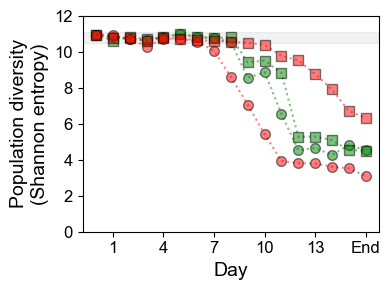

In [71]:
# Create a new figure for the plot
plt.figure(figsize=[4, 3])

# Create a new figure for the plot
plt.figure(figsize=[4, 3])

plt.plot(df_shannon.BiofilmPlank_AmkA, marker = 'o', linestyle = ':',markersize=7,\
         color = 'green', markeredgecolor = 'black', alpha = 0.5)

plt.plot(df_shannon.BiofilmPlank_AmkB, marker = 's', linestyle = ':',markersize=7,\
         color = 'green', markeredgecolor = 'black', alpha = 0.5)

plt.plot(df_shannon.BiofilmPlank_A, marker = 'o', linestyle = ':',markersize=7,\
         color = 'red', markeredgecolor = 'black', alpha = 0.5)

plt.plot(df_shannon.BiofilmPlank_B, marker = 's', linestyle = ':',markersize=7,\
         color = 'red', markeredgecolor = 'black', alpha = 0.5)

#plt.ylim([5,12])  # Optional: to set y-axis limits
plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Population diversity\n(Shannon entropy)', fontname='arial', fontsize=14)

# Custom tick labels for time points
plt.xticks([1, 4, 7, 10, 13, 16], [1, 4, 7, 10, 13,'End'], fontname='Arial', fontsize=12);
plt.yticks(fontname='Arial', fontsize=12);

# Highlight the variance in the initial data to identify when the diversity deviates from initial
plt.axhspan(
    10.8 - 2.52*0.13,
    10.8 + 2.52*0.13,
    color='gray', alpha=0.1
)

plt.ylim([0,12])

# Save the figure as an SVG for publication-quality output
plt.tight_layout()
plt.savefig('Figures paper/Amk_planktonic.svg', format='svg', dpi=300)

<Figure size 400x300 with 0 Axes>

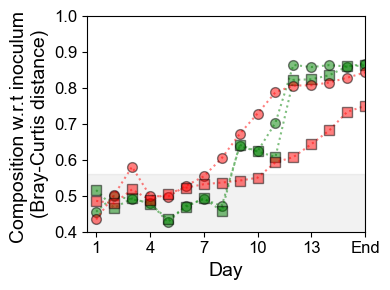

In [72]:
# Create a new figure for the plot
plt.figure(figsize=[4, 3])

# Create a new figure for the plot
plt.figure(figsize=[4, 3])

plt.plot(df_braycurtis.BiofilmPlank_AmkA[1:], marker = 'o', linestyle = ':',markersize=7,\
         color = 'green', markeredgecolor = 'black', alpha = 0.5)

plt.plot(df_braycurtis.BiofilmPlank_AmkB[1:], marker = 's', linestyle = ':',markersize=7,\
         color = 'green', markeredgecolor = 'black', alpha = 0.5)

plt.plot(df_braycurtis.BiofilmPlank_A[1:], marker = 'o', linestyle = ':',markersize=7,\
         color = 'red', markeredgecolor = 'black', alpha = 0.5)

plt.plot(df_braycurtis.BiofilmPlank_B[1:], marker = 's', linestyle = ':',markersize=7,\
         color = 'red', markeredgecolor = 'black', alpha = 0.5)

#plt.ylim([5,12])  # Optional: to set y-axis limits
plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Composition w.r.t inoculum \n(Bray-Curtis distance)', fontname='arial', fontsize=14)

# Custom tick labels for time points
plt.xticks([1, 4, 7, 10, 13, 16], [1, 4, 7, 10, 13,'End'], fontname='Arial', fontsize=12);
plt.yticks(fontname='Arial', fontsize=12);

# Highlight inoculum baseline (± 2.52 SD)
plt.axhspan(0.47-2.52*0.036, 0.47+2.52*0.036, color = 'gray', alpha = 0.1)

plt.ylim([0.4,1])
plt.xlim([0.5,16])

# Save the figure as an SVG for publication-quality output
plt.tight_layout()
plt.savefig('Figures paper/Amk_planktonic_braycurtis.svg', format='svg', dpi=300)

<Figure size 400x300 with 0 Axes>

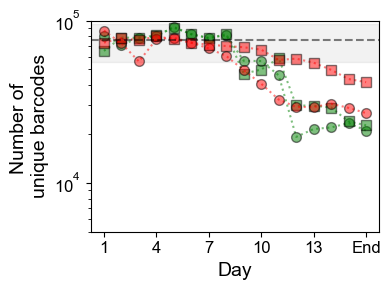

In [73]:
# Create a new figure for the plot
plt.figure(figsize=[4, 3])

# Create a new figure for the plot
plt.figure(figsize=[4, 3])

plt.plot(df_nb.BiofilmPlank_AmkA[1:], marker = 'o', linestyle = ':',markersize=7,\
         color = 'green', markeredgecolor = 'black', alpha = 0.5)

plt.plot(df_nb.BiofilmPlank_AmkB[1:], marker = 's', linestyle = ':',markersize=7,\
         color = 'green', markeredgecolor = 'black', alpha = 0.5)

plt.plot(df_nb.BiofilmPlank_A[1:], marker = 'o', linestyle = ':',markersize=7,\
         color = 'red', markeredgecolor = 'black', alpha = 0.5)

plt.plot(df_nb.BiofilmPlank_B[1:], marker = 's', linestyle = ':',markersize=7,\
         color = 'red', markeredgecolor = 'black', alpha = 0.5)

plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Number of \nunique barcodes', fontname='arial', fontsize=14)

# Custom tick labels for time points
plt.xticks([1, 4, 7, 10, 13, 16], [1, 4, 7, 10, 13,'End'], fontname='Arial', fontsize=12);
plt.yticks(fontname='Arial', fontsize=12);

# Highlight the variance in the initial data to identify when the diversity deviates from initial
plt.axhspan(
    75326 - 2.52*7901,
    75326 + 2.52*7901,
    color='gray', alpha=0.1
)
plt.axhline(y = 75326, color = 'black', linestyle ='--', alpha = 0.5)

plt.ylim(5000,100000)
plt.yscale('log')

# Save the figure as an SVG for publication-quality output
plt.tight_layout()
plt.savefig('Figures paper/Amk_planktonic_Nb.svg', format='svg', dpi=300)

In [74]:
def compute_shannon_and_bray(df, timepoints, baseline="3"):
    """Compute Shannon entropy and Bray–Curtis distance for a list of time points."""
    
    shannon_vals = []
    bray_vals = []
    nb = []
    base_freq = df[f"t_{baseline}_f"].fillna(0)
    
    for t in timepoints:
        col = f"t_{t}_f"
        
        # Filter out zeros for entropy
        freq = df.loc[df[col] > 0, col]

        # Shannon entropy: H = -Σ p log(p)
        shannon_vals.append(-(freq * np.log(freq)).sum())
        
        # Bray–Curtis distance against baseline
        bray_vals.append(
            distance.braycurtis(base_freq, df[col].fillna(0))
        )

        # Number of unique barcodes
        nb.append(
            len(df.loc[df[col] > 0])
        )
        
    return shannon_vals, bray_vals, nb

['3','6','26','38','41','62','69','77','98','106','114','133',\
              '7','27','39','45','63','73','81','99','107','115','137']

# --- Run sets A and B ---

set_A = ['3','10','43','79','118','145','170']
set_B = ['3','11','47','83','119','147','171']
set_C = ['3','6','38','62','77','106','133']
set_D = ['3','7','39','63','81','107','137']

set_E = ['3','8','42','78','116','144','168']
set_F = ['3','9','46','82','117','146','169']


df_shannon = pd.DataFrame()
df_braycurtis = pd.DataFrame()
df_Nb = pd.DataFrame()

df_shannon_control = pd.DataFrame()
df_braycurtis_control = pd.DataFrame()

df_shannon['Flask_AmkA'], df_braycurtis['Flask_AmkA'], df_Nb['Flask_AmkA'] = compute_shannon_and_bray(df_biofilm_filtered, set_C)
df_shannon['Flask_AmkB'], df_braycurtis['Flask_AmkB'], df_Nb['Flask_AmkB'] = compute_shannon_and_bray(df_biofilm_filtered, set_D)

df_shannon['BiofilmPlank_AmkA'], df_braycurtis['BiofilmPlank_AmkA'], df_Nb['BiofilmPlank_AmkA'] = compute_shannon_and_bray(df_biofilm_filtered, set_A)
df_shannon['BiofilmPlank_AmkB'], df_braycurtis['BiofilmPlank_AmkB'], df_Nb['BiofilmPlank_AmkB'] = compute_shannon_and_bray(df_biofilm_filtered, set_B)

df_shannon['BiofilmPlank_A'], df_braycurtis['BiofilmPlank_A'], df_Nb['BiofilmPlank_A'] = compute_shannon_and_bray(df_biofilm_filtered, set_E)
df_shannon['BiofilmPlank_B'], df_braycurtis['BiofilmPlank_B'], df_Nb['BiofilmPlank_B'] = compute_shannon_and_bray(df_biofilm_filtered, set_F)

df_shannon.to_excel('Figurewise raw data/5C. Amikacin Planktonic Shannon.xlsx')
df_braycurtis.to_excel('Figurewise raw data/Supplementary Figure 15B Amikacin Planktonic BrayCurtis.xlsx')
df_nb.to_excel('Figurewise raw data/Supplementary Figure 15B Amikacin Planktonic Nb.xlsx')

In [75]:
def compute_nb(df, timepoints, baseline="3"):
    """Compute Shannon entropy and Bray–Curtis distance for a list of time points."""
    
    nb = []
    
    base_freq = df[f"t_{baseline}_f"].fillna(0)
    
    for t in timepoints:
        col = f"t_{t}_f"

        # Shannon entropy: H = -Σ p log(p)
        nb.append(len(df.loc[df[col] > 0]))
        
        
        
    return nb


# --- Run sets A and B ---

set_A = ['3','10','43','79','118','145','170']
set_B = ['3','11','47','83','119','147','171']
set_C = ['3','6','38','62','77','106','133']
set_D = ['3','7','39','63','81','107','137']

set_E = ['3','8','42','78','116','144','168']
set_F = ['3','9','46','82','117','146','169']
df_Nb = pd.DataFrame()

df_Nb['BiofilmPlank_AmkA'] = compute_nb(df_biofilm_filtered, set_A)
df_Nb['BiofilmPlank_AmkB'] = compute_nb(df_biofilm_filtered, set_B)
df_Nb['Flask_AmkA'] = compute_nb(df_biofilm_filtered, set_C) 
df_Nb['Flask_AmkB'] = compute_nb(df_biofilm_filtered, set_D)
df_Nb['BiofilmPlank_A'] = compute_nb(df_biofilm_filtered, set_E) 
df_Nb['BiofilmPlank_B'] = compute_nb(df_biofilm_filtered, set_F)
df_Nb

,BiofilmPlank_AmkA,BiofilmPlank_AmkB,Flask_AmkA,Flask_AmkB,BiofilmPlank_A,BiofilmPlank_B
0,88551,88551,88551,88551,88551,88551
1,80716,64981,79987,68040,86746,73092
2,79884,81099,66430,60770,76717,79885
3,78351,77602,23608,35218,67269,70973
4,56279,49900,20328,31408,40782,66145
5,21462,29867,17860,18133,29298,54935
6,20980,22625,21915,11124,26892,41691


In [76]:
# The following code is to determine the Shannon entropy and Bray–Curtis index 
# for different discs over time. Each set (A–F) corresponds to a group of 
# timepoints measured for each disc.

set_A = ['12','48','84','120','148','172']   # Timepoints for Disc_A1
set_B = ['13','49','85','121','149','173']   # Timepoints for Disc_A2
set_C = ['14','50','86','122','150','174']   # Timepoints for Disc_A3
set_D = ['15','51','87','123','151','175']   # Timepoints for Disc_B1
set_E = ['16','52','88','124','152','176']   # Timepoints for Disc_B2
set_F = ['17','53','89','125','153','177']   # Timepoints for Disc_B3

# DataFrames to store the results for Shannon entropy and Bray–Curtis indices.
# The index corresponds to experiment-specific time identifiers (e.g., hours/days).
df_shannon_2 = pd.DataFrame(index=[1,4,7,10,13,16])
df_braycurtis_2 = pd.DataFrame(index=[1,4,7,10,13,16])
df_Nb_2 = pd.DataFrame(index=[1,4,7,10,13,16])

# Compute Shannon entropy and Bray–Curtis for each disc group in Set A
df_shannon_2['Disc_A1'], df_braycurtis_2['Disc_A1'], df_Nb_2['Disc_A1'] = compute_shannon_and_bray(df_biofilm_filtered, set_A)
df_shannon_2['Disc_A2'], df_braycurtis_2['Disc_A2'], df_Nb_2['Disc_A2'] = compute_shannon_and_bray(df_biofilm_filtered, set_B)
df_shannon_2['Disc_A3'], df_braycurtis_2['Disc_A3'], df_Nb_2['Disc_A3'] = compute_shannon_and_bray(df_biofilm_filtered, set_C)

# Compute Shannon entropy and Bray–Curtis for each disc group in Set B
df_shannon_2['Disc_B1'], df_braycurtis_2['Disc_B1'], df_Nb_2['Disc_B1'] = compute_shannon_and_bray(df_biofilm_filtered, set_D)
df_shannon_2['Disc_B2'], df_braycurtis_2['Disc_B2'], df_Nb_2['Disc_B2'] = compute_shannon_and_bray(df_biofilm_filtered, set_E)
df_shannon_2['Disc_B3'], df_braycurtis_2['Disc_B3'] , df_Nb_2['Disc_B3']= compute_shannon_and_bray(df_biofilm_filtered, set_F)

# Combine the newly computed values (df_shannon_2, df_braycurtis_2)
# with earlier computed DataFrames (df_shannon and df_braycurtis)
df_Shannon_Combined = pd.concat([df_shannon, df_shannon_2], axis = 1)
df_braycurtis_Combined = pd.concat([df_braycurtis, df_braycurtis_2], axis = 1)
df_Nb_Combined = pd.concat([df_Nb, df_Nb_2], axis = 1)

# Manually remove a known missing or invalid data point for Disc_B1 at index 8
df_Shannon_Combined.loc[7, 'Disc_B1'] = np.nan
df_braycurtis_Combined.loc[7, 'Disc_B1'] = np.nan

# Remove the first row of the Bray–Curtis combined table (index 1)
df_braycurtis_Combined = df_braycurtis_Combined[1:]


df_Nb_Combined

,BiofilmPlank_AmkA,BiofilmPlank_AmkB,Flask_AmkA,Flask_AmkB,BiofilmPlank_A,BiofilmPlank_B,Disc_A1,Disc_A2,Disc_A3,Disc_B1,Disc_B2,Disc_B3
0,88551.0,88551.0,88551.0,88551.0,88551.0,88551.0,NaN,NaN,NaN,NaN,NaN,NaN
1,80716.0,64981.0,79987.0,68040.0,86746.0,73092.0,21968.0,18835.0,16559.0,17797.0,18105.0,21953.0
2,79884.0,81099.0,66430.0,60770.0,76717.0,79885.0,NaN,NaN,NaN,NaN,NaN,NaN
3,78351.0,77602.0,23608.0,35218.0,67269.0,70973.0,NaN,NaN,NaN,NaN,NaN,NaN
4,56279.0,49900.0,20328.0,31408.0,40782.0,66145.0,32790.0,49451.0,73169.0,13390.0,44399.0,36357.0
5,21462.0,29867.0,17860.0,18133.0,29298.0,54935.0,NaN,NaN,NaN,NaN,NaN,NaN
6,20980.0,22625.0,21915.0,11124.0,26892.0,41691.0,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,38976.0,53962.0,46281.0,15.0,50622.0,39733.0
10,NaN,NaN,NaN,NaN,NaN,NaN,36391.0,40603.0,51996.0,37647.0,39649.0,50863.0
13,NaN,NaN,NaN,NaN,NaN,NaN,32030.0,30596.0,37854.0,29658.0,36730.0,41477.0


In [77]:
# The following code is to determine the Shannon entropy and Bray–Curtis index 
# for different discs over time. Each set (A–F) corresponds to a group of 
# timepoints measured for each disc.

set_A = ['18','54','90','126','154','178']   # Timepoints for Disc_AmkA1
set_B = ['19','55','91','127','155','179']   # Timepoints for Disc_AmkA2
set_C = ['20','56','92','128','156','180']   # Timepoints for Disc_AmkA3
set_D = ['21','57','93','129','157','181']   # Timepoints for Disc_AmkB1
set_E = ['22','58','94','130','158','182']   # Timepoints for Disc_AmkB2
set_F = ['23','59','95','131','159','183']   # Timepoints for Disc_AmkB3

# DataFrames to store the results for Shannon entropy and Bray–Curtis indices.
# The index corresponds to experiment-specific time identifiers (e.g., hours/days).
df_shannon_2 = pd.DataFrame(index=[1,4,7,10,13,16])
df_braycurtis_2 = pd.DataFrame(index=[1,4,7,10,13,16])
df_Nb_2 = pd.DataFrame(index=[1,4,7,10,13,16])

# Compute Shannon entropy and Bray–Curtis for each disc group in Set A
df_shannon_2['Disc_AmkA1'], df_braycurtis_2['Disc_AmkA1'], df_Nb_2['Disc_AmkA1'] = compute_shannon_and_bray(df_biofilm_filtered, set_A)
df_shannon_2['Disc_AmkA2'], df_braycurtis_2['Disc_AmkA2'], df_Nb_2['Disc_AmkA2'] = compute_shannon_and_bray(df_biofilm_filtered, set_B)
df_shannon_2['Disc_AmkA3'], df_braycurtis_2['Disc_AmkA3'], df_Nb_2['Disc_AmkA3'] = compute_shannon_and_bray(df_biofilm_filtered, set_C)

# Compute Shannon entropy and Bray–Curtis for each disc group in Set B
df_shannon_2['Disc_AmkB1'], df_braycurtis_2['Disc_AmkB1'], df_Nb_2['Disc_AmkB1'] = compute_shannon_and_bray(df_biofilm_filtered, set_D)
df_shannon_2['Disc_AmkB2'], df_braycurtis_2['Disc_AmkB2'], df_Nb_2['Disc_AmkB2'] = compute_shannon_and_bray(df_biofilm_filtered, set_E)
df_shannon_2['Disc_AmkB3'], df_braycurtis_2['Disc_AmkB3'], df_Nb_2['Disc_AmkB3'] = compute_shannon_and_bray(df_biofilm_filtered, set_F)


# Combine the newly computed values (df_shannon_2, df_braycurtis_2)
# with earlier computed DataFrames (df_shannon and df_braycurtis)
df_Shannon_Combined = pd.concat([df_Shannon_Combined, df_shannon_2], axis = 1)
df_braycurtis_Combined = pd.concat([df_braycurtis_Combined, df_braycurtis_2], axis = 1)
df_Nb_Combined = pd.concat([df_Nb_Combined, df_Nb_2], axis = 1)

# Manually remove a known missing or invalid data point for Disc_AmkB1 at index 8
#df_Shannon_Combined.loc[8, 'Disc_AmkB1'] = np.nan
#df_braycurtis_Combined.loc[8, 'Disc_AmkB1'] = np.nan

# Remove the first row of the Bray–Curtis combined table (index 1)
df_braycurtis_Combined = df_braycurtis_Combined


df_Shannon_Combined

,Flask_AmkA,Flask_AmkB,BiofilmPlank_AmkA,BiofilmPlank_AmkB,BiofilmPlank_A,BiofilmPlank_B,Disc_A1,Disc_A2,Disc_A3,Disc_B1,Disc_B2,Disc_B3,Disc_AmkA1,Disc_AmkA2,Disc_AmkA3,Disc_AmkB1,Disc_AmkB2,Disc_AmkB3
0,10.970045,10.970045,10.970045,10.970045,10.970045,10.970045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10.848580,10.666135,10.853811,10.622656,10.938095,10.759986,8.029155,8.506772,8.909176,8.461997,8.629758,8.860975,9.212440,8.689130,8.368796,9.408927,8.686519,9.288761
2,10.502212,10.415708,10.819338,10.839052,10.732609,10.801929,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9.066562,9.761095,10.752125,10.757803,10.064085,10.598658,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7.572815,9.491098,8.874745,9.520724,5.419000,10.391592,9.673548,10.236283,10.721030,8.267770,10.090872,9.823670,10.358943,10.141288,9.884792,9.906872,9.599927,10.682211
5,7.340593,8.274638,4.654919,5.289864,3.797481,8.770978,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6.891636,7.023720,4.527006,4.502006,3.103215,6.318176,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,9.635697,9.974704,9.867001,NaN,10.187140,9.926652,10.563855,10.092449,10.264265,9.731740,9.615924,10.743279
10,NaN,NaN,NaN,NaN,NaN,NaN,8.956434,8.388852,8.374851,9.437029,9.468736,9.843369,8.470059,8.285928,8.444345,9.036441,8.924650,9.783015
13,NaN,NaN,NaN,NaN,NaN,NaN,7.110262,7.165663,6.814731,8.479221,8.641921,7.715409,4.924100,4.835029,4.806334,5.501560,5.754752,5.733543


In [78]:
df_Shannon_Combined.to_csv('Figurewise raw data/5D. Amk Shannon discs.csv')
df_braycurtis_Combined.to_csv('Figurewise raw data/Supplementary figure 15 Distance from inoculum Discs.csv')
df_Nb_Combined.to_csv('Figurewise raw data/Supplementary figure 15 Nb Discs.csv')


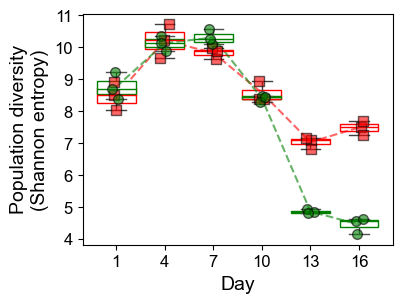

In [30]:
# Create a new figure for the plot
plt.figure(figsize=[4, 3])
# Prepare Disc_A1, Disc_A2, Disc_A3 Shannon values:
# - Drop NaN rows, transpose, stack, convert to long format.
df_data = pd.DataFrame(
    df_Shannon_Combined[['Disc_A1', 'Disc_A2', 'Disc_A3']].dropna().T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})

# Draw red boxplots for the disc data
sns.boxplot(
    x='Day', y='Shannon', data=df_data,
    boxprops=dict(facecolor='white', edgecolor='red'),
    medianprops=dict(color='red')
)

# Overlay red scatter points on top of the boxplots
sns.stripplot(
    x='Day', y='Shannon', data=df_data,
    color='red', alpha=0.6, s=7, marker = 's',
    edgecolor='black', linewidth=1, label=''
)

# Compute mean Shannon entropy per day for A1–A3 and draw dashed mean line
df = df_data[['Day', 'Shannon']].groupby('Day').mean()
plt.plot([0,1,2,3,4,5], df.Shannon, '--', color='red', alpha=0.6, label = '')

df_data = pd.DataFrame(
    df_Shannon_Combined[['Disc_AmkA1', 'Disc_AmkA2', 'Disc_AmkA3']].dropna().T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})


# Draw red boxplots for the disc data
sns.boxplot(
    x='Day', y='Shannon', data=df_data,
    boxprops=dict(facecolor='white', edgecolor='green'),
    medianprops=dict(color='green')
)

# Overlay red scatter points on top of the boxplots
sns.stripplot(
    x='Day', y='Shannon', data=df_data,
    color='green', alpha=0.6, s=7,
    edgecolor='black', linewidth=1, label=''
)

# Compute mean Shannon entropy per day for A1–A3 and draw dashed mean line
df = df_data[['Day', 'Shannon']].groupby('Day').mean()
plt.plot([0,1,2,3,4,5], df.Shannon, '--', color='green', alpha=0.6, label = '')

# --- Axis formatting ---

#plt.ylim([5,12])  # Optional: to set y-axis limits
plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Population diversity\n(Shannon entropy)', fontname='arial', fontsize=14)

# Custom tick labels for time points
plt.xticks([0,1,2,3,4,5], fontname='Arial', fontsize=12)

plt.yticks(fontname='Arial', fontsize=12);


# Save the figure as an SVG for publication-quality output
plt.savefig('Figures paper/WellAAmk_Shannon_Entropy.svg', format='svg', dpi=300)


In [31]:
#We do a comparison of diversity for the initial and second time point
import scipy.stats as stats
print(stats.ttest_ind(df_data.loc[df_data.Day == 1].Shannon, \
                      df_data.loc[df_data.Day == 4].Shannon))

print(stats.ttest_ind(df_data.loc[df_data.Day == 1].Shannon, \
                      df_data.loc[df_data.Day == 7].Shannon))

TtestResult(statistic=np.float64(-4.872597156392385), pvalue=np.float64(0.008204296589592174), df=np.float64(4.0))
TtestResult(statistic=np.float64(-5.500018044251451), pvalue=np.float64(0.005328065344088885), df=np.float64(4.0))


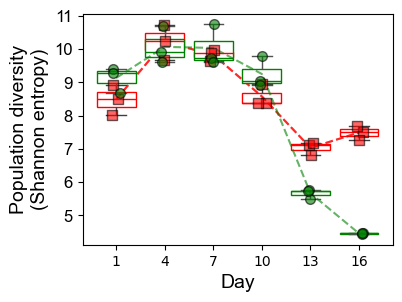

In [32]:
# Create a new figure for the Well B Shannon entropy plot
plt.figure(figsize=[4, 3])

# --- Plot 2: Red boxplots and stripplot for Disc_B1, Disc_B2, Disc_B3 ---

df_data = pd.DataFrame(
    df_Shannon_Combined[['Disc_A1', 'Disc_A2', 'Disc_A3']].dropna().T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})

# Draw red boxplots for the disc data
sns.boxplot(
    x='Day', y='Shannon', data=df_data,
    boxprops=dict(facecolor='white', edgecolor='red'),
    medianprops=dict(color='red')
)

# Overlay red scatter points on top of the boxplots
sns.stripplot(
    x='Day', y='Shannon', data=df_data,
    color='red', alpha=0.6, s=7, marker = 's',
    edgecolor='black', linewidth=1, label=''
)

# Compute and plot mean Shannon entropy per time point (red dashed line)
df = df_data[['Day', 'Shannon']].groupby('Day').mean()
plt.plot([0,1,2,3,4,5], df.Shannon, '--', color='red', alpha=0.6)


# Compute mean Shannon entropy per day for A1–A3 and draw dashed mean line
df = df_data[['Day', 'Shannon']].groupby('Day').mean()
plt.plot([0,1,2,3,4,5], df.Shannon, '--', color='red', alpha=0.6, label = '')


df_data = pd.DataFrame(
    df_Shannon_Combined[['Disc_AmkB1', 'Disc_AmkB2', 'Disc_AmkB3']].dropna().T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})

# Draw red boxplots for the disc data
sns.boxplot(
    x='Day', y='Shannon', data=df_data,
    boxprops=dict(facecolor='white', edgecolor='green'),
    medianprops=dict(color='green')
)

# Overlay red scatter points on top of the boxplots
sns.stripplot(
    x='Day', y='Shannon', data=df_data,
    color='green', alpha=0.6, s=7,
    edgecolor='black', linewidth=1, label=''
)

# Compute mean Shannon entropy per day for A1–A3 and draw dashed mean line
df = df_data[['Day', 'Shannon']].groupby('Day').mean()
plt.plot([0,1,2,3,4,5], df.Shannon, '--', color='green', alpha=0.6, label = '')

# --- Axis formatting ---

#plt.ylim([5,12])  # Optional: to set y-axis limits
plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Population diversity\n(Shannon entropy)', fontname='arial', fontsize=14)

# Custom tick labels for time points
#plt.xticks([0, 2, 5, 8, 11, 14, 16], fontname='Arial', fontsize=12)
plt.yticks(fontname='Arial', fontsize=12);


# Save the figure as an SVG for publication-quality output
plt.savefig('Figures paper/WellBAmk_Shannon_Entropy.svg', format='svg', dpi=300)


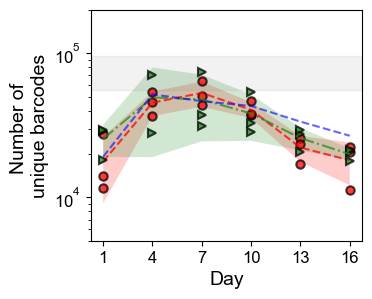

In [33]:
# Create a new figure for the plot
plt.figure(figsize=[3.5, 3])

# Prepare Disc_AmkA1, Disc_AmkA2, Disc_AmkA3 Shannon values:
# - Drop NaN rows, transpose, stack, convert to long format.
df_data = pd.DataFrame(
    df_Nb_Combined[['Disc_AmkA1', 'Disc_AmkA2', 'Disc_AmkA3']].dropna().T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})
df_data_A = df_data
df_data_A['Replicate'] = 'A'

for discname in ['Disc_AmkA1', 'Disc_AmkA2', 'Disc_AmkA3']:
    plt.plot(df_data_A.loc[df_data_A.Disc == discname].Day,\
             df_data_A.loc[df_data_A.Disc == discname].Shannon, 'o',\
             color = 'red',alpha = 0.75,  markeredgecolor='black', # This is your border color
        markeredgewidth=1.5, linewidth=1, label='')

# 1. Calculate Mean and Standard Deviation
stats_A = df_data_A.groupby('Day')['Shannon'].agg(['mean', 'std']).reset_index()

# 2. Plot the shaded area (Mean +/- 1 Standard Deviation)
plt.fill_between(
    stats_A.Day, 
    stats_A['mean'] - stats_A['std'], 
    stats_A['mean'] + stats_A['std'], 
    color='red', 
    alpha=0.2,       # Low alpha makes it a light "mist"
    edgecolor='none' # Removes the harsh outline around the shaded box
)

# 3. Plot the mean line (as you already have)
plt.plot(stats_A.Day, stats_A['mean'], color='red', linestyle='--', alpha=0.75)

# --- Plot 2: Red boxplots/points/mean line for Disc A1–A3 ---

# Prepare Disc_AmkB1, Disc_AmkB2, Disc_AmkB3 Shannon values:
# - Drop NaN rows, transpose, stack, convert to long format.
# Extract disc-level Shannon data (B1, B2, B3)
df_data = df_Nb_Combined[['Disc_AmkB1', 'Disc_AmkB2', 'Disc_AmkB3']]

# Remove any rows where Disc_AmkB2 is NaN (to keep the dataset aligned)
df_data = df_data.loc[pd.isna(df_data.Disc_AmkB2) == False]

# Convert disc data into long-format (stacked)
df_data = pd.DataFrame(
    df_data[['Disc_AmkB1', 'Disc_AmkB2', 'Disc_AmkB3']].T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})

df_data_B = df_data
df_data_B.loc[1,'Shannon'] = np.nan
df_data_B = df_data_B.dropna()

for discname in ['Disc_AmkB1', 'Disc_AmkB2', 'Disc_AmkB3']:
    plt.plot(df_data_B.loc[df_data_B.Disc == discname].Day,\
             df_data_B.loc[df_data_B.Disc == discname].Shannon, '>',\
             color = 'forestgreen',alpha = 0.75,  markeredgecolor='black', # This is your border color
        markeredgewidth=1.5, linewidth=1, label='')

# 1. Calculate Mean and Standard Deviation
stats_B = df_data_B.groupby('Day')['Shannon'].agg(['mean', 'std']).reset_index()

# 2. Plot the shaded area (Mean +/- 1 Standard Deviation)
plt.fill_between(
    stats_B.Day, 
    stats_B['mean'] - stats_B['std'], 
    stats_B['mean'] + stats_B['std'], 
    color='forestgreen', 
    alpha=0.2,       # Low alpha makes it a light "mist"
    edgecolor='none' # Removes the harsh outline around the shaded box
)

# 3. Plot the mean line (as you already have)
plt.plot(stats_B.Day, stats_B['mean'], color='forestgreen', linestyle='-.', alpha=0.75)


df_data = pd.DataFrame(
    df_Nb_Combined[['Disc_A1', 'Disc_A2', 'Disc_A3']].dropna().T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Nb'})

# Compute mean Nb entropy per day for A1–A3 and draw dashed mean line
df = df_data[['Day', 'Nb']].groupby('Day').mean()
plt.plot(stats_B.Day, df.Nb, '--', color='blue', alpha=0.6, label = '')

#plt.ylim([5,12])  # Optional manual y-axis limit
plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Number of \nunique barcodes', fontname='arial', fontsize=14)

# Custom x-axis tick positions
plt.xticks([1, 4, 7, 10, 13, 16], fontname='Arial', fontsize=12)
plt.yticks(fontname='Arial', fontsize=12)

plt.axhspan(
    75326 - 2.52*7901,
    75326 + 2.52*7901,
    color='gray', alpha=0.1
)

plt.ylim([5000,200000])
plt.yscale('log')

plt.savefig('Figures paper/WellA_AMK_Dsc_Nb.svg', format='svg', dpi=300)
#plt.yscale('log')

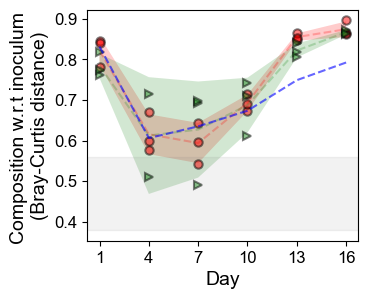

In [34]:
# Create a new figure for the plot
plt.figure(figsize=[3.5, 3])

# Convert the Shannon entropy values for BiofilmPlank_A into long format:
# - Transpose, stack into a long vector, then reset and rename columns.


# --- Plot 2: Red boxplots/points/mean line for Disc A1–A3 ---

# Prepare Disc_AmkA1, Disc_AmkA2, Disc_AmkA3 Shannon values:
# - Drop NaN rows, transpose, stack, convert to long format.
df_data = pd.DataFrame(
    df_braycurtis_Combined[['Disc_AmkA1', 'Disc_AmkA2', 'Disc_AmkA3']].dropna().T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})
df_data_A = df_data
df_data_A['Replicate'] = 'A'

for discname in ['Disc_AmkA1', 'Disc_AmkA2', 'Disc_AmkA3']:
    plt.plot(df_data_A.loc[df_data_A.Disc == discname].Day,\
             df_data_A.loc[df_data_A.Disc == discname].Shannon, 'o',\
             color = 'red',alpha = 0.5,  markeredgecolor='black', # This is your border color
        markeredgewidth=1.5, linewidth=1, label='')

# 1. Calculate Mean and Standard Deviation
stats_A = df_data_A.groupby('Day')['Shannon'].agg(['mean', 'std']).reset_index()

# 2. Plot the shaded area (Mean +/- 1 Standard Deviation)
plt.fill_between(
    stats_A.Day, 
    stats_A['mean'] - stats_A['std'], 
    stats_A['mean'] + stats_A['std'], 
    color='red', 
    alpha=0.2,       # Low alpha makes it a light "mist"
    edgecolor='none' # Removes the harsh outline around the shaded box
)

# 3. Plot the mean line (as you already have)
plt.plot(stats_A.Day, stats_A['mean'], color='red', linestyle='--', alpha=0.25)

df_data = df_braycurtis_Combined[['Disc_AmkB1', 'Disc_AmkB2', 'Disc_AmkB3']]

# Remove any rows where Disc_AmkB2 is NaN (to keep the dataset aligned)
df_data = df_data.loc[pd.isna(df_data.Disc_AmkB2) == False]

# Convert disc data into long-format (stacked)
df_data = pd.DataFrame(
    df_data[['Disc_AmkB1', 'Disc_AmkB2', 'Disc_AmkB3']].T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})

df_data_B = df_data
df_data_B.loc[1,'Shannon'] = np.nan
df_data_B = df_data_B.dropna()

for discname in ['Disc_AmkB1', 'Disc_AmkB2', 'Disc_AmkB3']:
    plt.plot(df_data_B.loc[df_data_B.Disc == discname].Day,\
             df_data_B.loc[df_data_B.Disc == discname].Shannon, '>',\
             color = 'forestgreen',alpha = 0.5,  markeredgecolor='black', # This is your border color
        markeredgewidth=1.5, linewidth=1, label='')

# 1. Calculate Mean and Standard Deviation
stats_B = df_data_B.groupby('Day')['Shannon'].agg(['mean', 'std']).reset_index()

# 2. Plot the shaded area (Mean +/- 1 Standard Deviation)
plt.fill_between(
    stats_B.Day, 
    stats_B['mean'] - stats_B['std'], 
    stats_B['mean'] + stats_B['std'], 
    color='forestgreen', 
    alpha=0.2,       # Low alpha makes it a light "mist"
    edgecolor='none' # Removes the harsh outline around the shaded box
)

# 3. Plot the mean line (as you already have)
plt.plot(stats_B.Day, stats_B['mean'], color='forestgreen', linestyle='--', alpha=0.25)


df_data = pd.DataFrame(
    df_braycurtis_Combined[['Disc_A1', 'Disc_A2', 'Disc_A3']].dropna().T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})

# Compute mean Nb entropy per day for A1–A3 and draw dashed mean line
df = df_data[['Day', 'Shannon']].groupby('Day').mean()
plt.plot(stats_B.Day, df.Shannon, '--', color='blue', alpha=0.6, label = '')

#plt.ylim([5,12])  # Optional manual y-axis limit
plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Composition w.r.t inoculum \n(Bray-Curtis distance)', fontname='arial', fontsize=14)

# Custom x-axis tick positions
plt.xticks([1, 4, 7, 10, 13, 16], fontname='Arial', fontsize=12)
plt.yticks(fontname='Arial', fontsize=12)

#plt.ylim([6.5,11.5])

# Highlight inoculum baseline (± 2.52 SD)
plt.axhspan(0.47-2.52*0.036, 0.47+2.52*0.036, color = 'gray', alpha = 0.1)

plt.savefig('Figures paper/WellA_Dsc_BrayCurtis_amk.svg', format='svg', dpi=300)


In [35]:
# ------------------------------------------------------------
# CLEAN UNIFIED SCRIPT FOR CALCULATING BRAY–CURTIS DISTANCES
# BETWEEN DISCS (A1–A2, A2–A3, ..., A3–B3)
# ------------------------------------------------------------

# Helper function to compute Bray–Curtis distances between two lists of timepoints
def compute_bray_list(df, list1, list2):
    """
    Compute Bray–Curtis distance between matched timepoints
    across two discs or samples.
    NaN values are replaced with zero.
    """
    distances = []
    for t1, t2 in zip(list1, list2):
        distances.append(distance.braycurtis(
            df['t_' + t1 + '_f'].replace(np.nan, 0),
            df['t_' + t2 + '_f'].replace(np.nan, 0)
        ))
    return distances


A1 = ['12','48','84','120','148','172']
A2 = ['13','49','85','121','149','173']
A3 = ['14','50','86','122','150','174']

B1 = ['15','51','87','123','151','175']
B2 = ['16','52','88','124','152','176']
B3 = ['17','53','89','125','153','177']


# ------------------------------------------------------------
# COMPUTE ALL REQUIRED DISC–DISC COMPARISONS
# ------------------------------------------------------------
df_braycurtis_disc = pd.DataFrame()

# Within-well comparisons (A)
df_braycurtis_disc['DiscA12'] = compute_bray_list(df_biofilm_filtered, A1, A2)
df_braycurtis_disc['DiscA23'] = compute_bray_list(df_biofilm_filtered, A2, A3)
df_braycurtis_disc['DiscA13'] = compute_bray_list(df_biofilm_filtered, A1, A3)

# Within-well comparisons (B)
df_braycurtis_disc['DiscB12'] = compute_bray_list(df_biofilm_filtered, B1, B2)
df_braycurtis_disc['DiscB23'] = compute_bray_list(df_biofilm_filtered, B2, B3)
df_braycurtis_disc['DiscB13'] = compute_bray_list(df_biofilm_filtered, B1, B3)

# Cross-well comparisons (A vs B)
df_braycurtis_disc['DiscA1B1'] = compute_bray_list(df_biofilm_filtered, A1, B1)
df_braycurtis_disc['DiscA2B2'] = compute_bray_list(df_biofilm_filtered, A2, B2)
df_braycurtis_disc['DiscA3B3'] = compute_bray_list(df_biofilm_filtered, A3, B3)


# ------------------------------------------------------------
# TIMEPOINT DEFINITIONS FOR EACH DISC
# Each group contains six timepoints for that disc
# ------------------------------------------------------------
A1 = ['18','54','90','126','154','178']
A2 = ['19','55','91','127','155','179']
A3 = ['20','56','92','128','156','180']

B1 = ['21','57','93','129','157','181']
B2 = ['22','58','94','130','158','182']
B3 = ['23','59','95','131','159','183']


# ------------------------------------------------------------
# COMPUTE ALL REQUIRED DISC–DISC COMPARISONS
# ------------------------------------------------------------

# Within-well comparisons (A)
df_braycurtis_disc['Amk_DiscA12'] = compute_bray_list(df_biofilm_filtered, A1, A2)
df_braycurtis_disc['Amk_DiscA23'] = compute_bray_list(df_biofilm_filtered, A2, A3)
df_braycurtis_disc['Amk_DiscA13'] = compute_bray_list(df_biofilm_filtered, A1, A3)

# Within-well comparisons (B)
df_braycurtis_disc['Amk_DiscB12'] = compute_bray_list(df_biofilm_filtered, B1, B2)
df_braycurtis_disc['Amk_DiscB23'] = compute_bray_list(df_biofilm_filtered, B2, B3)
df_braycurtis_disc['Amk_DiscB13'] = compute_bray_list(df_biofilm_filtered, B1, B3)

# Cross-well comparisons (A vs B)
df_braycurtis_disc['Amk_DiscA1B1'] = compute_bray_list(df_biofilm_filtered, A1, B1)
df_braycurtis_disc['Amk_DiscA2B2'] = compute_bray_list(df_biofilm_filtered, A2, B2)
df_braycurtis_disc['Amk_DiscA3B3'] = compute_bray_list(df_biofilm_filtered, A3, B3)




# ------------------------------------------------------------
# MANUAL ADJUSTMENT OF SPECIFIC TIMEPOINTS
# (Copied exactly from your original script)
# ------------------------------------------------------------
df_braycurtis_disc.loc[2, 'DiscB12'] = np.nan
df_braycurtis_disc.loc[2, 'DiscB13'] = np.nan
df_braycurtis_disc.loc[2, 'DiscA1B1'] = np.nan


# ------------------------------------------------------------
# SAVE TO FILE
# ------------------------------------------------------------
df_braycurtis_disc.to_excel(
    'Figurewise raw data/6G. Temporal Disc-Disc distance amikacin.xlsx'
)
df_braycurtis_disc

,DiscA12,DiscA23,DiscA13,DiscB12,DiscB23,DiscB13,DiscA1B1,DiscA2B2,DiscA3B3,Amk_DiscA12,Amk_DiscA23,Amk_DiscA13,Amk_DiscB12,Amk_DiscB23,Amk_DiscB13,Amk_DiscA1B1,Amk_DiscA2B2,Amk_DiscA3B3
0,0.900968,0.892536,0.904316,0.903488,0.890592,0.894816,0.912796,0.900416,0.882804,0.881456,0.896124,0.884860,0.865664,0.872784,0.847056,0.850772,0.888048,0.881132
1,0.736096,0.596116,0.694348,0.801572,0.660284,0.790056,0.833088,0.672872,0.647076,0.634992,0.684544,0.689788,0.746804,0.715088,0.674360,0.692832,0.712388,0.680324
2,0.630716,0.650676,0.676432,NaN,0.664964,NaN,NaN,0.652204,0.713984,0.661264,0.675776,0.622644,0.745752,0.687532,0.683556,0.708872,0.735956,0.604216
3,0.634744,0.545388,0.606904,0.649412,0.624624,0.619888,0.717468,0.761284,0.663688,0.450172,0.481124,0.491172,0.633084,0.577364,0.613256,0.756872,0.712436,0.716200
4,0.525028,0.516116,0.484248,0.628540,0.556416,0.629188,0.812160,0.811028,0.744068,0.187784,0.197920,0.153244,0.274984,0.276156,0.231256,0.550892,0.568168,0.540908
5,0.644616,0.634088,0.694780,0.621860,0.638392,0.545704,0.815068,0.831040,0.830012,0.258136,0.173360,0.267368,0.145908,0.145280,0.126288,0.580464,0.554264,0.580868


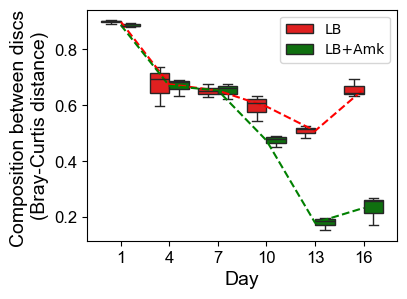

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the Bray–Curtis dataframe previously computed
df_Bray = df_braycurtis_disc

# Create a new figure for plotting
plt.figure(figsize= [4,3])

# ------------------------------------------------------------
# Prepare SAME-WELL DISC comparisons (B1–B2, B2–B3, B1–B3)
# ------------------------------------------------------------

# Select Bray–Curtis distances for same-well comparisons
df_plot = df_Bray[['DiscA12','DiscA23','DiscA13']]

# Remove rows where DiscA23 is missing (ensures complete rows)
df_plot = df_plot.loc[pd.isna(df_plot.DiscA23) == False]

# Convert wide format → long format for plotting
df_data = pd.DataFrame(
    df_plot[['DiscA12','DiscA23','DiscA13']].T.stack()
).reset_index().rename(columns={'level_0':'Disc','level_1':'Day',0:'Bray'})

# Label these as “Same Well”
df_data['Sample'] = 'LB'

# ------------------------------------------------------------
# Prepare INTER-WELL DISC comparisons (A1–B1, A2–B2, A3–B3)
# ------------------------------------------------------------

df_plot2 = df_Bray[['Amk_DiscA12','Amk_DiscA23','Amk_DiscA13']]
#df_plot2 = df_plot2.loc[pd.isna(df_plot2.DiscA2B2) == False]

# Wide → long format
df_data2 = pd.DataFrame(
    df_plot2[['Amk_DiscA12','Amk_DiscA23','Amk_DiscA13']].T.stack()
).reset_index().rename(columns={'level_0':'Disc','level_1':'Day',0:'Bray'})

# Label these as “Inter well”
df_data2['Sample'] = 'LB+Amk'

# Combine same-well and inter-well datasets
df_data3 = pd.concat([df_data, df_data2])

# ------------------------------------------------------------
# Plot boxplots comparing same-well vs inter-well Bray–Curtis
# ------------------------------------------------------------
sns.boxplot(
    x='Day', 
    y='Bray', 
    data=df_data3, 
    hue='Sample', 
    palette={"LB": "red", "LB+Amk": "green"}
)

# ------------------------------------------------------------
# Plot mean Bray–Curtis trend lines for each category
# ------------------------------------------------------------

# Mean across days for SAME-WELL
data = df_data[['Day','Bray']].groupby('Day').mean()
plt.plot([0,1,2,3,4,5], data.Bray, color='red', alpha=1, linestyle='--')

# Mean across days for INTER-WELL
data = df_data2[['Day','Bray']].groupby('Day').mean()
plt.plot([0,1,2,3,4,5], data.Bray, color='green', alpha=1, linestyle='--')

# ------------------------------------------------------------
# Formatting the figure
# ------------------------------------------------------------
plt.legend(ncol=1)

plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Composition between discs \n(Bray-Curtis distance)',
           fontname='arial', fontsize=14)

#plt.ylim([0.45,1])

plt.xticks([0,1,2,3,4,5], [1,4,7,10,13,16], fontname='Arial', fontsize=12)
plt.yticks(fontname='Arial', fontsize=12)

# Save figure
plt.savefig('Figures paper/DiscDisc_Braycurtis_intra_inter_A.svg',
            format='svg', dpi=300)


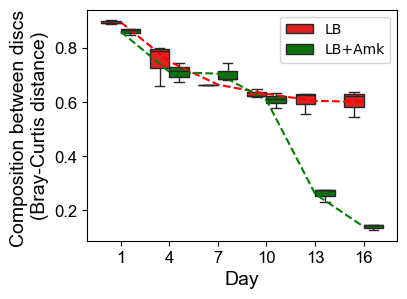

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the Bray–Curtis dataframe previously computed
df_Bray = df_braycurtis_disc

# Create a new figure for plotting
plt.figure(figsize= [4,3])

# ------------------------------------------------------------
# Prepare SAME-WELL DISC comparisons (B1–B2, B2–B3, B1–B3)
# ------------------------------------------------------------

# Select Bray–Curtis distances for same-well comparisons
df_plot = df_Bray[['DiscB12','DiscB23','DiscB13']]

# Remove rows where DiscB23 is missing (ensures complete rows)
df_plot = df_plot.loc[pd.isna(df_plot.DiscB23) == False]

# Convert wide format → long format for plotting
df_data = pd.DataFrame(
    df_plot[['DiscB12','DiscB23','DiscB13']].T.stack()
).reset_index().rename(columns={'level_0':'Disc','level_1':'Day',0:'Bray'})

# Label these as “Same Well”
df_data['Sample'] = 'LB'

# ------------------------------------------------------------
# Prepare INTER-WELL DISC comparisons (A1–B1, A2–B2, A3–B3)
# ------------------------------------------------------------

df_plot2 = df_Bray[['Amk_DiscB12','Amk_DiscB23','Amk_DiscB13']]
#df_plot2 = df_plot2.loc[pd.isna(df_plot2.DiscA2B2) == False]

# Wide → long format
df_data2 = pd.DataFrame(
    df_plot2[['Amk_DiscB12','Amk_DiscB23','Amk_DiscB13']].T.stack()
).reset_index().rename(columns={'level_0':'Disc','level_1':'Day',0:'Bray'})

# Label these as “Inter well”
df_data2['Sample'] = 'LB+Amk'

# Combine same-well and inter-well datasets
df_data3 = pd.concat([df_data, df_data2])

# ------------------------------------------------------------
# Plot boxplots comparing same-well vs inter-well Bray–Curtis
# ------------------------------------------------------------
sns.boxplot(
    x='Day', 
    y='Bray', 
    data=df_data3, 
    hue='Sample', 
    palette={"LB": "red", "LB+Amk": "green"}
)

# ------------------------------------------------------------
# Plot mean Bray–Curtis trend lines for each category
# ------------------------------------------------------------

# Mean across days for SAME-WELL
data = df_data[['Day','Bray']].groupby('Day').mean()
plt.plot([0,1,2,3,4,5], data.Bray, color='red', alpha=1, linestyle='--')

# Mean across days for INTER-WELL
data = df_data2[['Day','Bray']].groupby('Day').mean()
plt.plot([0,1,2,3,4,5], data.Bray, color='green', alpha=1, linestyle='--')

# ------------------------------------------------------------
# Formatting the figure
# ------------------------------------------------------------
plt.legend(ncol=1)

plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Composition between discs \n(Bray-Curtis distance)',
           fontname='arial', fontsize=14)

#plt.ylim([0.45,1])

plt.xticks([0,1,2,3,4,5], [1,4,7,10,13,16], fontname='Arial', fontsize=12)
plt.yticks(fontname='Arial', fontsize=12)

# Save figure
plt.savefig('Figures paper/DiscDisc_Braycurtis_intra_inter_B.svg',
            format='svg', dpi=300)


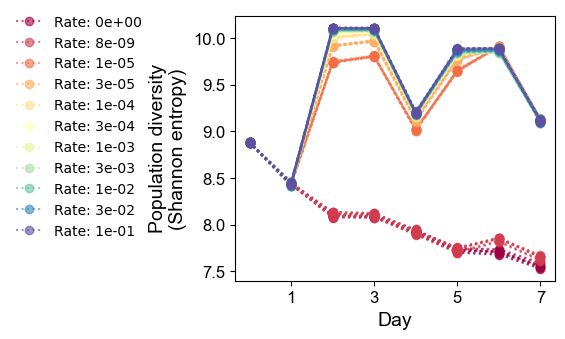

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Create a new figure - slightly wider to accommodate left legend
plt.figure(figsize=[6, 3.5])

df_simulation = pd.read_csv('Simulation_final/Temp/Shannon_amk_all.csv')

unique_rates = df_simulation.migration_rate.drop_duplicates().sort_values()
num_rates = len(unique_rates)
cmap = plt.get_cmap('Spectral') 

for i, rate in enumerate(unique_rates):
    line_color = cmap(i / (num_rates - 1)) if num_rates > 1 else cmap(0.5)
    df_rate = df_simulation[df_simulation.migration_rate == rate]
    
    for replicate in df_rate.replicate.unique():
        df = df_rate[df_rate.replicate == replicate]
        df = df.loc[df.cycle <= 7]
        
        # Formatting
        formatted_rate = f"{rate:.0e}" 
        label = f'Rate: {formatted_rate}' if replicate == 0 else ""
        
        plt.plot(df.cycle + 1, df.Disc, 'o:', color=line_color, 
                 alpha=0.6, label=label) # Lowered alpha slightly for better visibility of overlaps

plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Population diversity\n(Shannon entropy)', fontname='Arial', fontsize=14)
#plt.ylim([8, 11])

# Custom x-axis tick positions
plt.xticks([2,4,6,8], [1,3,5,7], fontname='Arial', fontsize=12);
plt.yticks(fontname='Arial', fontsize=12);

# --- LEGEND ON THE LEFT ---
plt.legend(bbox_to_anchor=(-0.25, 1.05), loc='upper right', frameon=False, fontsize=10)

# Adjust the plot area so the legend on the left is visible
# Increase 'left' value if your legend labels are very long
plt.subplots_adjust(left=0.25, right=0.95)
plt.tight_layout()
plt.savefig('Figures paper/Shannon_Left_Legend_amk.svg', format='svg')
plt.show()

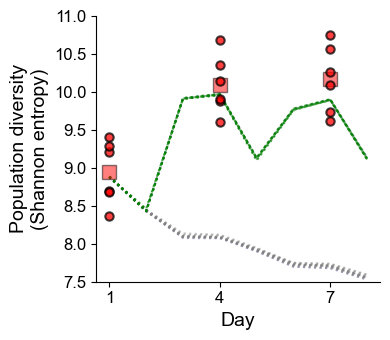

In [63]:
#--- Plot 0: Simulated data for how the population dynamics should look like ---
df_simulation = pd.read_csv('Simulation_final/Temp/Shannon_amk_all.csv')
df_simulation.to_csv('Figurewise raw data/5E. Simulation.csv')
# Create a new figure
plt.figure(figsize=[4, 3.5])

# Filter data for this rate
df_rate = df_simulation[df_simulation.migration_rate == 0]

for replicate in df_rate.replicate.unique():
    df = df_rate[df_rate.replicate == replicate]
    df = df.loc[df.cycle <= 7]
    # --- THE FORMATTING FIX ---
    # Format the rate to 1 decimal place in scientific notation
    formatted_rate = f"{rate:.1e}" 
        
    # Only label the first replicate so the legend stays clean
    label = f'Rate: {formatted_rate}' if replicate == 0 else ""
    if replicate == 0:  
        plt.plot(df.cycle + 1, df.Disc, ':', color=line_color, 
                     alpha=0.5, label='m=0')
    else:
        plt.plot(df.cycle + 1, df.Disc, ':', color='gray', 
                     alpha=0.5, label='')


# Filter data for this rate
df_rate = df_simulation[df_simulation.migration_rate == 10**(-4.5)]

for replicate in df_rate.replicate.unique():
    df = df_rate[df_rate.replicate == replicate]
    df = df.loc[df.cycle <= 7]
    # --- THE FORMATTING FIX ---
    # Format the rate to 1 decimal place in scientific notation
    formatted_rate = f"{rate:.1e}" 
        
    # Only label the first replicate so the legend stays clean
    label = f'Rate: {formatted_rate}' if replicate == 0 else ""
    if replicate == 0:  
        plt.plot(df.cycle + 1, df.Disc, ':', color=line_color, 
                     alpha=0.5, label='m = m_opt')
    else:
        plt.plot(df.cycle + 1, df.Disc, ':', color='green', 
                     alpha=0.5, label='')

plt.plot(df_mean_shannon.index+1, df_mean_shannon, 's', \
         markersize = 10, color = 'red', markeredgecolor = 'black', alpha = 0.5, label = 'Experiment')

df_data = pd.DataFrame(
    df_Shannon_Combined[['Disc_AmkA1','Disc_AmkA2','Disc_AmkA3']].dropna().T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})
df_data_A = df_data
df_data_A['Replicate'] = 'A'

df_data_A = df_data_A.loc[df_data_A.Day <= 7]
for discname in ['Disc_AmkA1','Disc_AmkA2','Disc_AmkA3']:
    plt.plot(df_data_A.loc[df_data_A.Disc == discname].Day,\
             df_data_A.loc[df_data_A.Disc == discname].Shannon, 'o',\
             color = 'red',alpha = 0.75,  markeredgecolor='black', # This is your border color
        markeredgewidth=1.5, linewidth=1, label='')

# Extract disc-level Shannon data (B1, B2, B3)
df_data = df_Shannon_Combined[['Disc_AmkB1','Disc_AmkB2','Disc_AmkB3']]

# Remove any rows where Disc_B2 is NaN (to keep the dataset aligned)
#df_data = df_data.loc[pd.isna(df_data.Disc_B2) == False]

df_data = pd.DataFrame(
    df_data[['Disc_AmkB1','Disc_AmkB2','Disc_AmkB3']].T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})

df_data_B = df_data
#df_data_B.loc[1,'Shannon'] = np.nan
df_data_B = df_data_B.dropna()

df_data_B = df_data_B.loc[df_data_B.Day <= 7]

for discname in ['Disc_AmkB1','Disc_AmkB2','Disc_AmkB3']:
    plt.plot(df_data_B.loc[df_data_B.Disc == discname].Day,\
             df_data_B.loc[df_data_B.Disc == discname].Shannon, 'o',\
             color = 'red',alpha = 0.75,  markeredgecolor='black', # This is your border color
        markeredgewidth=1.5, linewidth=1, label='')

plt.ylim([7.5,11])

#plt.ylim([5,12])  # Optional manual y-axis limit
plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Population diversity\n(Shannon entropy)', fontname='arial', fontsize=14)

#plt.legend(ncol = 3)

# Custom x-axis tick positions
plt.xticks([1, 4, 7], fontname='Arial', fontsize=12);
plt.yticks(fontname='Arial', fontsize=12);

# Remove top and right spines
sns.despine(top=True, right=True)

plt.tight_layout()
plt.savefig('Figures paper/Temporal bestfit amk.svg', format='svg')
plt.show()

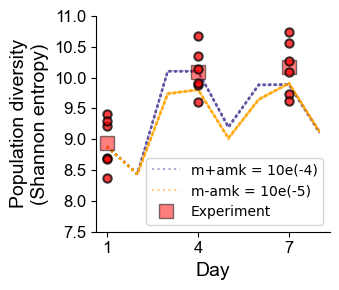

In [42]:

#--- Plot 0: Simulated data for how the population dynamics should look like ---
df_simulation = pd.read_csv('Simulation_final/Temp/Shannon_amk_all.csv')

import matplotlib.pyplot as plt
import numpy as np

# Create a new figure
plt.figure(figsize=[3.5, 3])

# Filter data for this rate
df_rate = df_simulation[df_simulation.migration_rate == best_row.rate]
    
for replicate in df_rate.replicate.unique():
    df = df_rate[df_rate.replicate == replicate]
    df = df.loc[df.cycle <= 7]
    # --- THE FORMATTING FIX ---
    # Format the rate to 1 decimal place in scientific notation
    formatted_rate = f"{rate:.1e}" 
        
    # Only label the first replicate so the legend stays clean
    label = f'Rate: {formatted_rate}' if replicate == 0 else ""
    if replicate == 0:  
        plt.plot(df.cycle + 1, df.Disc, ':', color=line_color, 
                     alpha=0.5, label='m+amk = 10e(-4)')
    else:
        plt.plot(df.cycle + 1, df.Disc, ':', color=line_color, 
                     alpha=0.5, label='')

# Filter data for this rate
df_rate = df_simulation[df_simulation.migration_rate == 0.00001]
    
for replicate in df_rate.replicate.unique():
    df = df_rate[df_rate.replicate == replicate]
    df = df.loc[df.cycle <= 7]
    # --- THE FORMATTING FIX ---
    # Format the rate to 1 decimal place in scientific notation
    formatted_rate = f"{rate:.1e}" 
        
    # Only label the first replicate so the legend stays clean
    label = f'Rate: {formatted_rate}' if replicate == 0 else ""
    if replicate == 0:  
        plt.plot(df.cycle + 1, df.Disc, ':', color='orange', 
                     alpha=0.5, label='m-amk = 10e(-5)')
    else:
        plt.plot(df.cycle + 1, df.Disc, ':', color='orange', 
                     alpha=0.5, label='')

plt.xlabel('Cycle', fontname='Arial', fontsize=12)
plt.ylabel('Disc Shannon Entropy', fontname='Arial', fontsize=12)

plt.tight_layout()

plt.plot(df_mean_shannon.index+1, df_mean_shannon, 's', \
         markersize = 10, color = 'red', markeredgecolor = 'black', alpha = 0.5, label = 'Experiment')

df_data = pd.DataFrame(
    df_Shannon_Combined[['Disc_AmkA1','Disc_AmkA2','Disc_AmkA3']].dropna().T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})
df_data_A = df_data
df_data_A['Replicate'] = 'A'

df_data_A = df_data_A.loc[df_data_A.Day <= 7]
for discname in ['Disc_AmkA1','Disc_AmkA2','Disc_AmkA3']:
    plt.plot(df_data_A.loc[df_data_A.Disc == discname].Day,\
             df_data_A.loc[df_data_A.Disc == discname].Shannon, 'o',\
             color = 'red',alpha = 0.75,  markeredgecolor='black', # This is your border color
        markeredgewidth=1.5, linewidth=1, label='')

# Extract disc-level Shannon data (B1, B2, B3)
df_data = df_Shannon_Combined[['Disc_AmkB1','Disc_AmkB2','Disc_AmkB3']]

# Remove any rows where Disc_B2 is NaN (to keep the dataset aligned)
#df_data = df_data.loc[pd.isna(df_data.Disc_B2) == False]

df_data = pd.DataFrame(
    df_data[['Disc_AmkB1','Disc_AmkB2','Disc_AmkB3']].T.stack()
).reset_index().rename(columns={'level_1': 'Day', 'level_0': 'Disc', 0: 'Shannon'})

df_data_B = df_data
#df_data_B.loc[1,'Shannon'] = np.nan
df_data_B = df_data_B.dropna()

df_data_B = df_data_B.loc[df_data_B.Day <= 7]

for discname in ['Disc_AmkB1','Disc_AmkB2','Disc_AmkB3']:
    plt.plot(df_data_B.loc[df_data_B.Disc == discname].Day,\
             df_data_B.loc[df_data_B.Disc == discname].Shannon, 'o',\
             color = 'red',alpha = 0.75,  markeredgecolor='black', # This is your border color
        markeredgewidth=1.5, linewidth=1, label='')

plt.ylim([7.5,11])

#plt.ylim([5,12])  # Optional manual y-axis limit
plt.xlabel('Day', fontname='Arial', fontsize=14)
plt.ylabel('Population diversity\n(Shannon entropy)', fontname='arial', fontsize=14)

plt.legend()

# Custom x-axis tick positions
plt.xticks([1, 4, 7], fontname='Arial', fontsize=12);
plt.yticks(fontname='Arial', fontsize=12);

# Remove top and right spines
sns.despine(top=True, right=True)

plt.tight_layout()
plt.savefig('Figures paper/Temporal bestfit amk.svg', format='svg')
plt.show()


In [34]:
#We import the table with all the barcodes whose genoemes were sequenced at the end of the experiment
df_flask = pd.read_excel('Biofilm-Amk.xlsx', index_col=0)
df_flask= \
df_flask.assign(True_Barcode = \
                          df_flask.Identified_Barcode.str[2:7]+df_flask.Identified_Barcode.str[9:14]+\
                          df_flask.Identified_Barcode.str[16:21]+df_flask.Identified_Barcode.str[23:28])

#We isolate all the barcodes that have been sequenced in table called df_subset
df_subset = df_biofilm_filtered.loc[
    df_biofilm_filtered.index.isin(df_flask.True_Barcode)
].copy()

#We make a table with only the mutated barcodes
df_mutatedbarcodes = df_flask.loc[(df_flask.gene != 'No Mutation')]

#All the barcodes that are mutated as assigned a tag 'Yes' for columns mutated
df_subset.loc[:,'Mutated'] = 'No'
df_subset.loc[df_subset.index.isin(df_mutatedbarcodes.True_Barcode),'Mutated'] = 'Yes'

df_subset.Mutated.value_counts()

Mutated
Yes    87
Name: count, dtype: int64

In [35]:
df_flask.loc[df_flask.True_Barcode.isin(df_subset.index) == False]

,Sample,Sample.1,Barcode,Identified_Barcode,Counts,Fitness,Disk 1,Disk 2,Frequency Plk,Frequency Disk 1,Frequency Disk 2,position,mutation,annotation,gene,description,True_Barcode


In [36]:
import numpy as np
import pandas as pd
from itertools import combinations, product

# --- ENRICHMENT THRESHOLD ---
cols = [f"t_{i}_enrichment" for i in range(8, 12)]
enrichment_values = [
    df_biofilm_filtered[col].mean() + 1.96 * df_biofilm_filtered[col].std()
    for col in cols
]
enrichment_threshold = np.mean(enrichment_values) + 1.96 * np.std(enrichment_values)

enrichment_threshold

np.float64(0.6360058016531004)

In [37]:
A1 = ['18','54','90','126','154','178']
A2 = ['19','55','91','127','155','179']
A3 = ['20','56','92','128','156','180']

B1 = ['21','57','93','129','157','181']
B2 = ['22','58','94','130','158','182']
B3 = ['23','59','95','131','159','183']

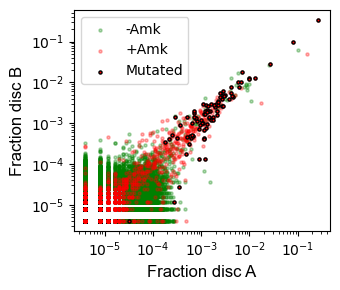

In [38]:
plt.figure(figsize=[3.5,3])


df = df_biofilm_filtered.loc[(df_biofilm_filtered['176'] >= 1)|\
                                 (df_biofilm_filtered['177'] >= 1)]
plt.scatter(df.t_176_f, df.t_177_f, color='green', alpha = 0.3, s = 5, rasterized = True, label = '-Amk')

df = df_biofilm_filtered.loc[(df_biofilm_filtered['178'] >= 1)|\
                                 (df_biofilm_filtered['179'] >= 1)]
plt.scatter(df.t_178_f, df.t_179_f, alpha = 0.3, color='red', s = 5, rasterized = True, label = '+Amk')

plt.scatter(df_subset.t_178_f, df_subset.t_179_f, alpha = 1, s = 5, color='red', label = 'Mutated', edgecolor = 'black', rasterized = True)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Fraction disc A', fontname = 'Arial', fontsize = 12)
plt.ylabel('Fraction disc B', fontname = 'Arial', fontsize = 12)

plt.legend(ncol = 1)

plt.tight_layout()

plt.savefig('Figures paper/Sampled Mutations AMK.svg', format = 'svg', dpi = 300)

In [84]:
import numpy as np
import pandas as pd
from itertools import combinations, product

# --- ENRICHMENT THRESHOLD ---
cols = [f"t_{i}_enrichment" for i in range(8, 12)]
enrichment_values = [
    df_biofilm_filtered[col].mean() + 1.96 * df_biofilm_filtered[col].std()
    for col in cols
]
enrichment_threshold = np.mean(enrichment_values) + 1.96 * np.std(enrichment_values)

enrichment_threshold

# ------------------------------------------------------------
# TIMEPOINT DEFINITIONS FOR EACH DISC in replicate B
# Each group contains six timepoints for that disc
# ------------------------------------------------------------
A1 = ['18','54','90','126','154','178']
A2 = ['19','55','91','127','155','179']
A3 = ['20','56','92','128','156','180']

records = []

for i in range(len(A1)):
    mask = (
        (df_biofilm_filtered['t_'+A1[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+A2[i]+'_enrichment'] < enrichment_threshold) &
        (df_biofilm_filtered['t_'+A3[i]+'_enrichment'] < enrichment_threshold)
    )
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+A1[i]+'_f'].sum()
    records.append({
            'Sample': 'One disc',
            'Time': i,
            'Fraction': fraction_sum
        })
for i in range(len(A2)):
    mask = (
        (df_biofilm_filtered['t_'+A2[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+A1[i]+'_enrichment'] < enrichment_threshold) &
        (df_biofilm_filtered['t_'+A3[i]+'_enrichment'] < enrichment_threshold)
    )
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+A2[i]+'_f'].sum()
    records.append({
            'Sample': 'One disc',
            'Time': i,
            'Fraction': fraction_sum
        })
    
for i in range(len(A3)):
    mask = (
        (df_biofilm_filtered['t_'+A3[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+A1[i]+'_enrichment'] < enrichment_threshold) &
        (df_biofilm_filtered['t_'+A2[i]+'_enrichment'] < enrichment_threshold)
    )
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+A3[i]+'_f'].sum()
    records.append({
            'Sample': 'One disc',
            'Time': i,
            'Fraction': fraction_sum
        })

for i in range(len(A1)):
    mask = (
        (df_biofilm_filtered['t_'+A1[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+A2[i]+'_enrichment'] >= enrichment_threshold))
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+A1[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+A2[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })

for i in range(len(A1)):
    mask = (
        (df_biofilm_filtered['t_'+A1[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+A3[i]+'_enrichment'] >= enrichment_threshold))
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+A1[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+A3[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })
    
for i in range(len(A1)):
    mask = (
        (df_biofilm_filtered['t_'+A2[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+A3[i]+'_enrichment'] >= enrichment_threshold))
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+A3[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+A2[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })

df_probability_enrichment = pd.DataFrame(records)
#df_probability_enrichment.loc[2,'Fraction'] = np.nan
#df_probability_enrichment.loc[22,'Fraction'] = np.nan
df_probability_enrichment

,Sample,Time,Fraction
0,One disc,0,0.628300
1,One disc,1,0.192364
2,One disc,2,0.144524
3,One disc,3,0.106992
4,One disc,4,0.007936
5,One disc,5,0.006828
6,One disc,0,0.705144
7,One disc,1,0.200288
8,One disc,2,0.286096
9,One disc,3,0.122080


In [85]:
import numpy as np
import pandas as pd
from itertools import combinations, product

# --- ENRICHMENT THRESHOLD ---
cols = [f"t_{i}_enrichment" for i in range(8, 12)]
enrichment_values = [
    df_biofilm_filtered[col].mean() + 1.96 * df_biofilm_filtered[col].std()
    for col in cols
]
enrichment_threshold = np.mean(enrichment_values) + 1.96 * np.std(enrichment_values)

enrichment_threshold

# ------------------------------------------------------------
# TIMEPOINT DEFINITIONS FOR EACH DISC in replicate B
# Each group contains six timepoints for that disc
# ------------------------------------------------------------
B1 = ['15','51','87','123','151','175']
B2 = ['16','52','88','124','152','176']
B3 = ['17','53','89','125','153','177']

records = []

for i in range(len(B1)):
    mask = (
        (df_biofilm_filtered['t_'+B1[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+B2[i]+'_enrichment'] < enrichment_threshold) &
        (df_biofilm_filtered['t_'+B3[i]+'_enrichment'] < enrichment_threshold)
    )
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B1[i]+'_f'].sum()
    records.append({
            'Sample': 'One disc',
            'Time': i,
            'Fraction': fraction_sum
        })
for i in range(len(B2)):
    mask = (
        (df_biofilm_filtered['t_'+B2[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+B1[i]+'_enrichment'] < enrichment_threshold) &
        (df_biofilm_filtered['t_'+B3[i]+'_enrichment'] < enrichment_threshold)
    )
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B2[i]+'_f'].sum()
    records.append({
            'Sample': 'One disc',
            'Time': i,
            'Fraction': fraction_sum
        })
    
for i in range(len(B3)):
    mask = (
        (df_biofilm_filtered['t_'+B3[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+B1[i]+'_enrichment'] < enrichment_threshold) &
        (df_biofilm_filtered['t_'+B2[i]+'_enrichment'] < enrichment_threshold)
    )
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B3[i]+'_f'].sum()
    records.append({
            'Sample': 'One disc',
            'Time': i,
            'Fraction': fraction_sum
        })

for i in range(len(B1)):
    mask = (
        (df_biofilm_filtered['t_'+B1[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+B2[i]+'_enrichment'] >= enrichment_threshold))
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B1[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B2[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })

for i in range(len(B1)):
    mask = (
        (df_biofilm_filtered['t_'+B1[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+B3[i]+'_enrichment'] >= enrichment_threshold))
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B1[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B3[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })
    
for i in range(len(B1)):
    mask = (
        (df_biofilm_filtered['t_'+B2[i]+'_enrichment'] >= enrichment_threshold) &
        (df_biofilm_filtered['t_'+B3[i]+'_enrichment'] >= enrichment_threshold))
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B3[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })
    fraction_sum = df_biofilm_filtered.loc[mask, 't_'+B2[i]+'_f'].sum()
    records.append({
            'Sample': 'Two disc',
            'Time': i,
            'Fraction': fraction_sum
        })

df_probability_enrichment_B = pd.DataFrame(records)
df_probability_enrichment_B.loc[2,'Fraction'] = np.nan
df_probability_enrichment_B.loc[22,'Fraction'] = np.nan
df_probability_enrichment_B

,Sample,Time,Fraction
0,One disc,0,0.730380
1,One disc,1,0.545608
2,One disc,2,NaN
3,One disc,3,0.230548
4,One disc,4,0.394372
5,One disc,5,0.085544
6,One disc,0,0.719724
7,One disc,1,0.248924
8,One disc,2,0.250256
9,One disc,3,0.279052


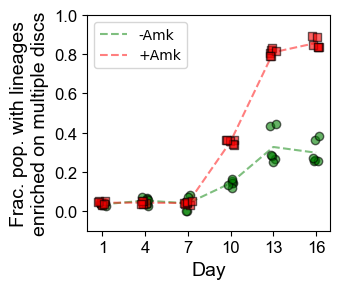

In [109]:
plt.figure(figsize = [3.5,3])

# Red-edged white boxplots for Disc B data
sns.stripplot(x='Time', y='Fraction', data=df_probability_enrichment_B.loc[df_probability_enrichment_B.Sample == 'Two disc'], color='green', alpha=0.6,
              s=6, edgecolor='black', marker="o", linewidth=1, label = '' )

plt.plot([0,1,2,3,4,5], df_probability_enrichment_B.loc[df_probability_enrichment_B['Sample'] == 'Two disc']\
[['Time', 'Fraction']].groupby('Time').mean(), '--', color = 'green', label = '-Amk', alpha = 0.5)

# Red-edged white boxplots for Disc B data
sns.stripplot(x='Time', y='Fraction', data=df_probability_enrichment.loc[df_probability_enrichment.Sample == 'Two disc'], color='red', alpha=0.6,
              s=6, edgecolor='black', marker="s", linewidth=1, label = '' )

plt.plot([0,1,2,3,4,5], df_probability_enrichment.loc[df_probability_enrichment['Sample'] == 'Two disc']\
[['Time', 'Fraction']].groupby('Time').mean(), '--', color = 'red', label = '+Amk', alpha = 0.5)

plt.legend()

plt.xlabel('Day', fontname = 'Arial', fontsize = 14)
plt.ylabel('Frac. pop. with lineages\nenriched on multiple discs', fontname = 'Arial', fontsize = 14)
plt.legend(ncol = 1, fontsize = 10)

plt.xticks([0,1,2,3,4,5], [1,4,7,10,13,16], fontname='Arial', fontsize=12)
plt.yticks(fontname = 'Arial', fontsize = 12)

plt.ylim([-0.1,1])

plt.tight_layout()

plt.savefig('Figures paper/Binding probability temporal Amk.svg', format = 'svg', dpi = 300)

In [98]:
print(df_probability_enrichment.loc[(df_probability_enrichment.Sample == 'Two disc') \
& (df_probability_enrichment.Time == 4)].Fraction.mean())
print(df_probability_enrichment.loc[(df_probability_enrichment.Sample == 'Two disc') \
& (df_probability_enrichment.Time == 4)].Fraction.std())

0.8098946666666668
0.015827393097622447


In [100]:
print(df_probability_enrichment_B.loc[(df_probability_enrichment_B.Sample == 'Two disc') \
& (df_probability_enrichment.Time == 4)].Fraction.mean())
print(df_probability_enrichment_B.loc[(df_probability_enrichment_B.Sample == 'Two disc') \
& (df_probability_enrichment.Time == 4)].Fraction.std())

0.32699866666666666
0.08772910948292287


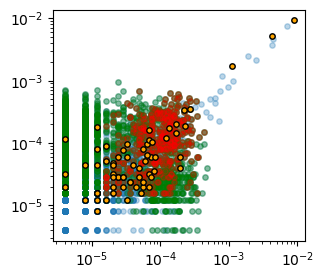

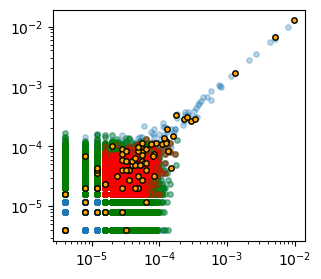

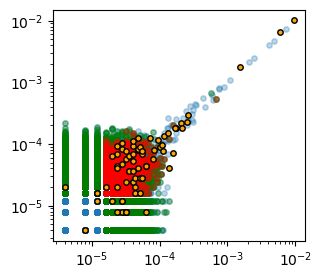

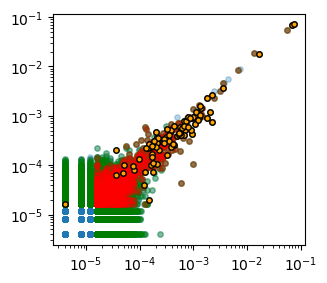

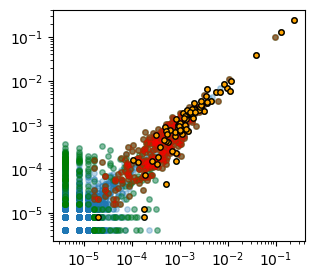

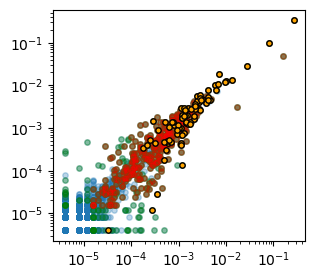

In [60]:
A1 = ['18','54','90','126','154','178']
A2 = ['19','55','91','127','155','179']

for i in range(len(A1)):
    df_plot = df_biofilm_filtered
    plt.figure(figsize=[3.25,3])
    plt.scatter(df_plot['t_'+A1[i]+'_f'],df_plot['t_'+A2[i]+'_f'], s = 15, alpha = 0.3, rasterized = True)

    #plot the correlation between the frequencies for all barcodes enrihed in discA
    df1 = df_plot.loc[(df_plot['t_'+A1[i]+'_enrichment'] >= enrichment_threshold)]
    plt.scatter(df1['t_'+A1[i]+'_f'], df1['t_'+A2[i]+'_f'], s = 15, alpha = 0.3, color = 'green', rasterized = True)

    #plot the correlation between the frequencies for all barcodes enrihed in discB
    df2 = df_plot.loc[(df_plot['t_'+A2[i]+'_enrichment'] >= enrichment_threshold)]
    plt.scatter(df2['t_'+A1[i]+'_f'], df2['t_'+A2[i]+'_f'], s = 15, alpha = 0.3, color = 'green', rasterized = True)

    #plot the correlation between the frequencies for all barcodes enrihed in disc A amd disc B
    df3 = df_plot.loc[(df_plot['t_'+A1[i]+'_enrichment'] >= enrichment_threshold) & (df_plot['t_'+A2[i]+'_enrichment'] >= enrichment_threshold)]
    plt.scatter(df3['t_'+A1[i]+'_f'], df3['t_'+A2[i]+'_f'], s = 15, alpha = 0.3, color = 'red', rasterized = True)

    df_plot = df_subset.loc[(df_subset.Mutated == 'Yes')]
    plt.scatter(df_plot['t_'+A1[i]+'_f'], df_plot['t_'+A2[i]+'_f'], s = 15, edgecolor = 'black',rasterized = True, color = 'orange')
    
    plt.xscale('log')
    plt.yscale('log')

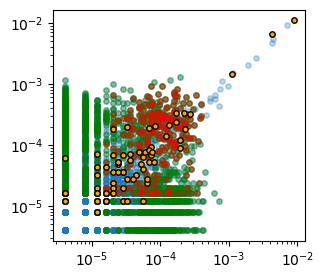

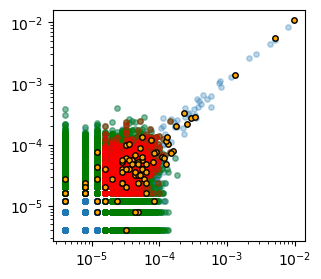

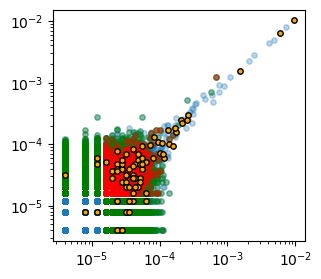

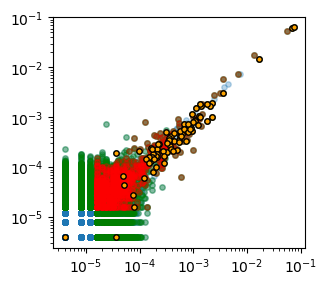

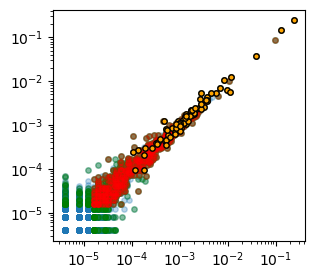

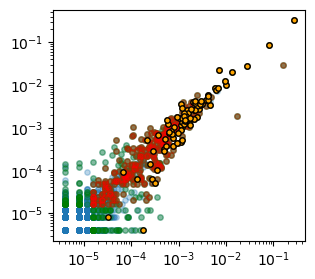

In [62]:
A1 = ['18','54','90','126','154','178']
A2 = ['20','56','92','128','156','180']

for i in range(len(A1)):
    df_plot = df_biofilm_filtered
    plt.figure(figsize=[3.25,3])
    plt.scatter(df_plot['t_'+A1[i]+'_f'],df_plot['t_'+A2[i]+'_f'], s = 15, alpha = 0.3, rasterized = True)

    #plot the correlation between the frequencies for all barcodes enrihed in discA
    df1 = df_plot.loc[(df_plot['t_'+A1[i]+'_enrichment'] >= enrichment_threshold)]
    plt.scatter(df1['t_'+A1[i]+'_f'], df1['t_'+A2[i]+'_f'], s = 15, alpha = 0.3, color = 'green', rasterized = True)

    #plot the correlation between the frequencies for all barcodes enrihed in discB
    df2 = df_plot.loc[(df_plot['t_'+A2[i]+'_enrichment'] >= enrichment_threshold)]
    plt.scatter(df2['t_'+A1[i]+'_f'], df2['t_'+A2[i]+'_f'], s = 15, alpha = 0.3, color = 'green', rasterized = True)

    #plot the correlation between the frequencies for all barcodes enrihed in disc A amd disc B
    df3 = df_plot.loc[(df_plot['t_'+A1[i]+'_enrichment'] >= enrichment_threshold) & (df_plot['t_'+A2[i]+'_enrichment'] >= enrichment_threshold)]
    plt.scatter(df3['t_'+A1[i]+'_f'], df3['t_'+A2[i]+'_f'], s = 15, alpha = 0.3, color = 'red', rasterized = True)

    df_plot = df_subset.loc[(df_subset.Mutated == 'Yes')]
    plt.scatter(df_plot['t_'+A1[i]+'_f'], df_plot['t_'+A2[i]+'_f'], s = 15, edgecolor = 'black',rasterized = True, color = 'orange')
    
    plt.xscale('log')
    plt.yscale('log')